In [6]:
# =========================
# Step 10.1 · Params: 评测工具与 I/O 准备
# =========================
from pathlib import Path

# 统一的中间文件目录（只读写 ./tmp）
TMP_DIR = Path("./tmp").resolve()

# 评测使用的截断 K（指标 @K）
K_EVAL = 20

# 数值容差（用于稳定性检查）
ATOL = 1e-8

# 需要评测的方法前缀（之后会逐个评测；本格只写工具）
METHOD_PREFIXES = {
    "Fused3-RA":   "S_fused3_symrow",
    "Tag-SGNS":    "S_tag_symrow",
    "Text-SGNS":   "S_text_symrow",
    "Behavior":    "S_beh_symrow",
    # 经典非嵌入基线会在 10.3 里另行构造（Text-BM25/Tag-PPMI 的 kNN）
}

# 运行环境信息（可选打印）
print(f"[Env] TMP_DIR = {TMP_DIR}")
print(f"[Eval] K_EVAL = {K_EVAL}")


[Env] TMP_DIR = /home/koyo/workspace/recsys/tmp
[Eval] K_EVAL = 20


In [7]:
# =========================
# Step 10.1 · Execute: 评测与I/O工具
# =========================
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List
from collections import defaultdict

def _require(p: Path, desc: str):
    if not p.exists():
        raise FileNotFoundError(f"[FATAL] 缺少 {desc}: {p.as_posix()}")

def load_manifest(prefix: str) -> Tuple[int, List[Path]]:
    """读取某个方法前缀的 manifest，返回 (nodes, parts)。"""
    mans = sorted(TMP_DIR.glob(f"{prefix}_k*_manifest.json"))
    if not mans:
        raise FileNotFoundError(f"[FATAL] 未找到 {prefix} 的 manifest")
    mp = mans[0]
    man = json.loads(mp.read_text())
    parts = [TMP_DIR / p for p in man["parts"]]
    nodes = int(man.get("nodes", 0))
    print(f"[MAN] {mp.name}  nodes={nodes:,}  parts={len(parts)}  nnz={int(man.get('nnz',0)):,}")
    return nodes, parts

def build_topk_for_method(prefix: str, k_eval: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    为某相似图（行随机、分片 Parquet）构建每行按权重降序的 Top-k 列表。
    返回：
        nbr_idx: (N, k_eval) 邻居 doc_idx，空位=-1
        nbr_w  : (N, k_eval) 对应权重，空位=0
    说明：
      - 我们的对齐图（*_symrow）每行已有 ≤50 条边，但分片顺序未必排序；
        这里对每行做一次小规模 top-k 选择，保证评测次序正确。
      - 实现采用“逐行合并老的 top-k 和新候选（≤50）再选 k_eval”的策略，内存友好。
    """
    N, parts = load_manifest(prefix)
    # 预分配：每行 k_eval 个槽位
    nbr_idx = np.full((N, k_eval), -1, dtype=np.int64)
    nbr_w   = np.zeros((N, k_eval), dtype=np.float32)

    # 为每行维护“已收集数量”计数（最多 50 以内），用于合并比较
    # 实际合并时直接拼接已有 k_eval + 新候选，做一次 argpartition 取前 k_eval
    for i, fp in enumerate(parts, 1):
        df = pd.read_parquet(fp, engine="fastparquet")  # 必有列: row, col, val
        # 用 groupby 将同一行的候选一起处理
        for row, g in df.groupby("row", sort=False):
            row = int(row)
            cand_c = g["col"].to_numpy(np.int64, copy=False)
            cand_w = g["val"].to_numpy(np.float32, copy=False)

            # 取已有 + 新候选 合并再选 top-k
            old_c = nbr_idx[row]
            old_w = nbr_w[row]
            # 拼接（过滤空位）
            mask_old = old_c >= 0
            if mask_old.any():
                cc = np.concatenate([old_c[mask_old], cand_c])
                ww = np.concatenate([old_w[mask_old], cand_w])
            else:
                cc, ww = cand_c, cand_w

            # 若出现重复邻居，做聚合（取最大权重）
            if cc.size > 1:
                ords = np.argsort(cc, kind="mergesort")
                cc = cc[ords]; ww = ww[ords]
                # 压缩重复 key，取 max
                uniq, start = np.unique(cc, return_index=True)
                maxw = np.maximum.reduceat(ww, start)
                cc, ww = uniq, maxw

            # 选前 k_eval
            if cc.size > k_eval:
                part = np.argpartition(ww, -k_eval)[-k_eval:]
                ord2 = np.argsort(-ww[part])
                sel = part[ord2]
                topc = cc[sel]; topw = ww[sel]
            else:
                # 不足 k_eval 就保留全部，并按权重降序排一下（便于指标）
                ord2 = np.argsort(-ww)
                topc = cc[ord2]; topw = ww[ord2]

            # 回写到固定长度槽位
            nk = min(k_eval, topc.size)
            nbr_idx[row, :nk] = topc[:nk]
            nbr_w[row,  :nk]  = topw[:nk]
            if nk < k_eval:
                nbr_idx[row, nk:] = -1
                nbr_w[row,  nk:]  = 0.0

        if (i % 4) == 0 or i == len(parts):
            print(f"[LOAD] {i}/{len(parts)} parts processed for {prefix}")

        del df

    # 稳健性检查（可选）
    rows_no_neighbor = int(np.sum(nbr_idx[:, 0] == -1))
    print(f"[TOPK] {prefix}: rows with no neighbors in top-{k_eval} = {rows_no_neighbor}")
    return nbr_idx, nbr_w

# ---------- 评价指标（@K） ----------
def dcg_at_k(rels: np.ndarray) -> float:
    """rels: 长度<=K 的增益数组（非负），已按排名次序对齐。"""
    if rels.size == 0:
        return 0.0
    ranks = np.arange(1, rels.size + 1)
    return float(np.sum(rels / np.log2(ranks + 1)))

def ndcg_at_k(gains_sorted: np.ndarray, gains_ideal_sorted: np.ndarray) -> float:
    """gains_sorted 为系统返回顺序的增益；gains_ideal_sorted 为理想排序的增益（均取@K）。"""
    dcg = dcg_at_k(gains_sorted)
    idcg = dcg_at_k(gains_ideal_sorted) if gains_ideal_sorted.size else 0.0
    return float(dcg / (idcg + ATOL))

def average_precision_at_k(rels_binary: np.ndarray) -> float:
    """AP@K（binary 相关）。rels_binary: 0/1 数组，对应排名。"""
    if rels_binary.size == 0:
        return 0.0
    hits = 0
    s = 0.0
    for i, r in enumerate(rels_binary, 1):
        if r > 0:
            hits += 1
            s += hits / i
    return float(s / max(1, int(rels_binary.sum())))

def mrr_at_k(rels_binary: np.ndarray) -> float:
    """MRR@K：第一个相关的位置的倒数（无相关则0）。"""
    pos = np.flatnonzero(rels_binary > 0)
    return float(1.0 / (pos[0] + 1)) if pos.size > 0 else 0.0

def precision_at_k(rels_binary: np.ndarray) -> float:
    K = max(1, rels_binary.size)
    return float(np.sum(rels_binary > 0) / K)

def recall_at_k(rels_binary: np.ndarray, total_rel: int) -> float:
    if total_rel <= 0:
        return 0.0
    return float(np.sum(rels_binary > 0) / total_rel)

print("[Step 10.1] 工具加载完成。后续可用 build_topk_for_method() 得到各方法的 Top-K 邻居用于评测；指标函数已就绪。")


[Step 10.1] 工具加载完成。后续可用 build_topk_for_method() 得到各方法的 Top-K 邻居用于评测；指标函数已就绪。


In [13]:
# =========================
# Step 10.2 · Params: 银标相关性构造与缓存
# =========================
from pathlib import Path

TMP_DIR = Path("./tmp").resolve()

# 输入产物（前面步骤已生成）
DOC_CLEAN_PATH   = TMP_DIR / "doc_clean.parquet"   # 含 doc_idx, Id, tag_list（已标准化为小写）
TAG_VOCAB_PATH   = TMP_DIR / "tag_vocab.parquet"   # 含至少 'tag' 与 'df'（或类似命名）
BEH_BASE_PATH    = TMP_DIR / "beh_base.parquet"    # 含 CreatorUserId, OwnerOrganizationId, 以及 log1p 指标等

# 输出缓存（本步生成）
TAG_DOCS_OUT     = TMP_DIR / "relevance_tag_docs.parquet"   # 每个 doc 的“保留标签列表”（仅 kept tags）
TAG_IDF_OUT      = TMP_DIR / "relevance_tag_idf.parquet"    # tag → df, idf
TAG_MANIFEST     = TMP_DIR / "relevance_tag_manifest.json"  # 统计信息

ORG_REL_OUT      = TMP_DIR / "relevance_org.parquet"        # doc_idx → org_id_int（缺失=-1）
CREATOR_REL_OUT  = TMP_DIR / "relevance_creator.parquet"    # doc_idx → creator_id_int（缺失=-1)

print(f"[Env] TMP_DIR = {TMP_DIR}")
print("[Plan] 将生成三套银标：Tag(graded) / Org(binary) / Creator(binary)")


[Env] TMP_DIR = /home/koyo/workspace/recsys/tmp
[Plan] 将生成三套银标：Tag(graded) / Org(binary) / Creator(binary)


In [15]:
# =========================
# Step 10.2 · Execute (Robust): 构造三套银标相关性并缓存
# =========================
import json
import numpy as np
import pandas as pd
from pathlib import Path

def _require(p: Path, desc: str):
    if not p.exists():
        raise FileNotFoundError(f"[FATAL] 缺少 {desc}: {p.as_posix()}")

_require(DOC_CLEAN_PATH, "doc_clean.parquet")
_require(TAG_VOCAB_PATH, "tag_vocab.parquet")
_require(BEH_BASE_PATH, "beh_base.parquet")

# 可选：优先使用 PPMI 的 D–T（更鲁棒），若不存在则退回到 bin
DT_PPMI_PATH = TMP_DIR / "DT_ppmi.parquet"
DT_BIN_PATH  = TMP_DIR / "DT_bin.parquet"
_use_dt_path = None
if DT_PPMI_PATH.exists():
    _use_dt_path = DT_PPMI_PATH
elif DT_BIN_PATH.exists():
    _use_dt_path = DT_BIN_PATH
else:
    raise FileNotFoundError("[FATAL] 未找到 DT_ppmi.parquet 或 DT_bin.parquet，用于在缺失 tag_list 时恢复每文档的标签列表。")

# ---------- (0) 基础信息 ----------
doc_df = pd.read_parquet(DOC_CLEAN_PATH, engine="fastparquet")
N = len(doc_df)
if "doc_idx" in doc_df.columns:
    assert (doc_df["doc_idx"].to_numpy() == np.arange(N)).all(), "[FATAL] doc_clean 未按 0..N-1 对齐"

beh = pd.read_parquet(BEH_BASE_PATH, engine="fastparquet")
assert len(beh) == N, "[FATAL] beh_base 与 doc_clean 行数不一致"
if "doc_idx" in beh.columns:
    assert (beh["doc_idx"].to_numpy() == np.arange(N)).all(), "[FATAL] beh_base 未按 0..N-1 对齐"

# ---------- (A) Tag-Relevance（graded） ----------
# 读取 tag vocab，识别列名并计算 idf
tag_vocab = pd.read_parquet(TAG_VOCAB_PATH, engine="fastparquet")
cols = {c.lower(): c for c in tag_vocab.columns}

tag_col = None
for cand in ["tag", "term", "token", "label", "name"]:
    if cand in cols:
        tag_col = cols[cand]; break
assert tag_col is not None, f"[FATAL] 未在 {TAG_VOCAB_PATH.name} 找到标签列"

df_col = None
for cand in ["df", "doc_freq", "docs", "count"]:
    if cand in cols:
        df_col = cols[cand]; break
assert df_col is not None, f"[FATAL] 未在 {TAG_VOCAB_PATH.name} 找到 df/doc_freq 列"

keep_col = cols.get("keep", None)
if keep_col is not None:
    tag_vocab = tag_vocab[tag_vocab[keep_col].astype(bool)]

# 统一小写并计算 idf
tag_vocab[tag_col] = tag_vocab[tag_col].astype(str).str.strip().str.lower()
df_vals = tag_vocab[df_col].astype(np.int64).to_numpy()
idf_vals = np.log((N + 1) / (df_vals + 1))
tag_idf_df = pd.DataFrame({
    "tag": tag_vocab[tag_col].astype(str).to_numpy(),
    "df":  df_vals,
    "idf": idf_vals.astype(np.float32)
}).drop_duplicates(subset=["tag"])
kept_tags = set(tag_idf_df["tag"].tolist())

# --- 关键分支：是否存在 doc_clean['tag_list'] ---
def _ensure_list(x):
    if isinstance(x, list):
        return [str(t).strip().lower() for t in x if isinstance(t, (str, int, float))]
    if pd.isna(x):
        return []
    s = str(x)
    if s.startswith("[") and s.endswith("]"):
        s = s.strip("[]")
        parts = [p.strip().strip("'").strip('"') for p in s.split(",")]
        return [p.lower() for p in parts if p]
    return [p.strip().lower() for p in s.split(",") if p.strip()]

if "tag_list" in doc_df.columns:
    # 直接用 doc_clean 的 tag_list，过滤到 kept_tags
    tags_series = doc_df["tag_list"].apply(_ensure_list)
    tags_kept = tags_series.apply(lambda lst: [t for t in lst if t in kept_tags])

else:
    # 无 tag_list：从 D–T 边恢复每文档的 kept_tag 列表
    print(f"[TAG] doc_clean 不含 'tag_list'；改用 { _use_dt_path.name } 恢复每文档标签列表 ...")
    dt = pd.read_parquet(_use_dt_path, engine="fastparquet")  # columns: row, col, val
    # 需要 col→tag 的映射：从 tag_vocab 里构建（按出现顺序即词典索引）
    # 假设 tag_vocab 与 DT 的列索引一致，如不一致需在保存 vocab 时一并保存 'col' 索引。
    # 我们在之前的实现里 vocab 顺序即列索引，这里稳妥起见做一列 'col'：
    if "col" in tag_vocab.columns:
        col_to_tag = dict(zip(tag_vocab["col"].astype(int).to_numpy(), tag_vocab[tag_col].to_numpy()))
    else:
        # 退路：按当前排序视为 0..V-1
        tag_vocab = tag_vocab.reset_index(drop=True)
        col_to_tag = dict(zip(np.arange(len(tag_vocab), dtype=np.int64), tag_vocab[tag_col].to_numpy()))
    # 只保留出现在 kept_tags 的列（若 vocab 与 kept 同源，这一步可省；这里双保险）
    # 先反向得到 tag->col，再以 col 过滤
    tag_to_col = {v: k for k, v in col_to_tag.items()}
    kept_cols = np.array([tag_to_col[t] for t in kept_tags if t in tag_to_col], dtype=np.int64)
    kept_cols_mask = pd.Series(False, index=np.unique(list(col_to_tag.keys())))
    kept_cols_mask.loc[kept_cols] = True

    # 过滤到 kept 列后，按 row 聚合出每行的 tag 列表
    # 如果 kept_cols 不完全覆盖 dt['col'] 的全集，使用布尔过滤更稳
    if "col" in dt.columns:
        dt_kept = dt[dt["col"].isin(kept_cols)]
        grp = dt_kept.groupby("row")["col"].apply(lambda xs: [col_to_tag[int(c)] for c in xs.unique()])
    else:
        raise KeyError("[FATAL] D–T 矩阵缺少 'col' 列")

    # 构建完整 N 行的列表（缺失行补空列表）
    tags_list = [grp.get(i, []) for i in range(N)]
    tags_kept = pd.Series(tags_list, index=np.arange(N, dtype=np.int64))

# 输出 tag 文档列表与 idf
tag_docs_df = pd.DataFrame({
    "doc_idx": np.arange(N, dtype=np.int64),
    "tags": tags_kept
})
n_has = int((tag_docs_df["tags"].apply(len) > 0).sum())

tag_docs_df.to_parquet(TAG_DOCS_OUT, engine="fastparquet", index=False)
tag_idf_df.to_parquet(TAG_IDF_OUT, engine="fastparquet", index=False)

man_tag = {
    "nodes": int(N),
    "docs_with_kept_tag": int(n_has),
    "docs_with_kept_tag_ratio": float(n_has / max(1, N)),
    "vocab_size": int(len(tag_idf_df)),
    "note": "Tag-Relevance 使用共享 kept_tags 的 idf 和作为增益；当 doc_clean 无 tag_list 时从 D–T 矩阵恢复每文档标签。"
}
Path(TAG_MANIFEST).write_text(json.dumps(man_tag, ensure_ascii=False, indent=2))
print(f"[TAG] docs_with_kept_tag={n_has:,}/{N:,}  vocab={len(tag_idf_df):,}")
print(f"[SAVE] {TAG_DOCS_OUT.name}, {TAG_IDF_OUT.name}, {Path(TAG_MANIFEST).name}")

# ---------- (B) Org-Relevance（binary） ----------
org_series = beh["OwnerOrganizationId"]
org_mapped = org_series.fillna(-1).astype(np.int64)
org_rel_df = pd.DataFrame({"doc_idx": np.arange(N, dtype=np.int64), "org_id": org_mapped.to_numpy(np.int64)})
org_rel_df.to_parquet(ORG_REL_OUT, engine="fastparquet", index=False)
print(f"[ORG] unique org (含-1) = {org_rel_df['org_id'].nunique()} | 缺失数={(org_rel_df['org_id'] == -1).sum():,}")
print(f"[SAVE] {ORG_REL_OUT.name}")

# ---------- (C) Creator-Relevance（binary） ----------
creator_series = beh["CreatorUserId"]
creator_mapped = creator_series.fillna(-1).astype(np.int64)
creator_rel_df = pd.DataFrame({"doc_idx": np.arange(N, dtype=np.int64), "creator_id": creator_mapped.to_numpy(np.int64)})
creator_rel_df.to_parquet(CREATOR_REL_OUT, engine="fastparquet", index=False)
print(f"[CREATOR] unique creators (含-1) = {creator_rel_df['creator_id'].nunique()} | 缺失数={(creator_rel_df['creator_id'] == -1).sum():,}")
print(f"[SAVE] {CREATOR_REL_OUT.name}")

print("\n[Step 10.2] DONE: 已生成三套银标缓存（Tag/Org/Creator）。")


[TAG] doc_clean 不含 'tag_list'；改用 DT_ppmi.parquet 恢复每文档标签列表 ...
[TAG] docs_with_kept_tag=214,585/521,735  vocab=394
[SAVE] relevance_tag_docs.parquet, relevance_tag_idf.parquet, relevance_tag_manifest.json
[ORG] unique org (含-1) = 391 | 缺失数=519,156
[SAVE] relevance_org.parquet
[CREATOR] unique creators (含-1) = 192013 | 缺失数=0
[SAVE] relevance_creator.parquet

[Step 10.2] DONE: 已生成三套银标缓存（Tag/Org/Creator）。


In [16]:
# =========================
# Step 10.3 · Params: 评测主方法（Fused3-RA / Text-SGNS / Tag-SGNS / Behavior）
# =========================
from pathlib import Path

TMP_DIR = Path("./tmp").resolve()

# 评测截断 @K
K_EVAL = 20

# 本格要评测的方法及其前缀（读取 *_symrow_* 的分片）
METHOD_PREFIXES = {
    "Fused3-RA":   "S_fused3_symrow",
    "Text-SGNS":   "S_text_symrow",
    "Tag-SGNS":    "S_tag_symrow",
    "Behavior":    "S_beh_symrow",
}

# 相关性缓存（10.2 生成）
TAG_DOCS_PATH    = TMP_DIR / "relevance_tag_docs.parquet"    # doc_idx,tags(list[str])
TAG_IDF_PATH     = TMP_DIR / "relevance_tag_idf.parquet"     # tag,df,idf（本格先不启用 idf）
ORG_REL_PATH     = TMP_DIR / "relevance_org.parquet"         # doc_idx, org_id
CREATOR_REL_PATH = TMP_DIR / "relevance_creator.parquet"     # doc_idx, creator_id

# 输出聚合表
OUT_CSV = TMP_DIR / "metrics_main.csv"

print(f"[Env] TMP_DIR={TMP_DIR}")
print(f"[Eval] K_EVAL={K_EVAL}")


[Env] TMP_DIR=/home/koyo/workspace/recsys/tmp
[Eval] K_EVAL=20


In [17]:
# =========================
# Step 10.3 · Execute: 主方法评测
# =========================
import json, numpy as np, pandas as pd
from collections import defaultdict

# ---- 复用 10.1 的工具（确保你已在 10.1 运行过）----
# - build_topk_for_method(prefix, k_eval)
# - 指标函数：ndcg_at_k, average_precision_at_k, mrr_at_k, precision_at_k, recall_at_k

def _require(p: Path, desc: str):
    if not p.exists():
        raise FileNotFoundError(f"[FATAL] 缺少 {desc}: {p.as_posix()}")

_require(TAG_DOCS_PATH,    "relevance_tag_docs.parquet")
_require(ORG_REL_PATH,     "relevance_org.parquet")
_require(CREATOR_REL_PATH, "relevance_creator.parquet")

# ---------- 载入三套银标 ----------
tag_docs = pd.read_parquet(TAG_DOCS_PATH, engine="fastparquet")   # doc_idx, tags(list[str])
N = len(tag_docs)
assert (tag_docs["doc_idx"].to_numpy() == np.arange(N)).all(), "[FATAL] tag_docs 未按 0..N-1 对齐"

org_df = pd.read_parquet(ORG_REL_PATH, engine="fastparquet")      # doc_idx, org_id
creator_df = pd.read_parquet(CREATOR_REL_PATH, engine="fastparquet")  # doc_idx, creator_id
assert len(org_df) == N and len(creator_df) == N, "[FATAL] Org/Creator 长度不一致"

org_ids     = org_df["org_id"].to_numpy(np.int64)
creator_ids = creator_df["creator_id"].to_numpy(np.int64)

# ---------- 为 Tag-Relevance 构建快速判定 ----------
# 把每个 doc 的标签转为 set；同时建立倒排：tag -> set(doc_idx)
doc_tags = [set(lst) if isinstance(lst, list) else set() for lst in tag_docs["tags"].tolist()]
inv_index = defaultdict(set)
for i, tags in enumerate(doc_tags):
    for t in tags:
        inv_index[t].add(i)

# 为 org/creator 预先计算“每个 doc 的总相关数”（Recall 的分母）
# - org：同 org 的文档数 - 1（剔除自身）；org==-1 的样本无可评
# - creator：同 creator 的文档数 - 1（剔除自身）；creator==-1 不会出现（缺失为 0）
def counts_by_id(arr: np.ndarray) -> np.ndarray:
    # 将 id 压缩到 [0..M) 再 bincount
    uniq, inv = np.unique(arr, return_inverse=True)
    cnt = np.bincount(inv)
    return cnt[inv]  # 与 arr 同长

org_cnt_all     = counts_by_id(org_ids)        # 包含自身
creator_cnt_all = counts_by_id(creator_ids)

org_total_rel     = np.where(org_ids >= 0, np.maximum(0, org_cnt_all - 1), 0)
creator_total_rel = np.maximum(0, creator_cnt_all - 1)

# 为 Tag：每个 doc 的“总相关数”（至少共享一个 kept tag）
# 计算方式：对该 doc 的每个 tag，把倒排里的 doc 集合做集合并，最后减去自身
tag_total_rel = np.zeros(N, dtype=np.int32)
for i, tags in enumerate(doc_tags):
    if not tags:
        continue
    # 小集合并（doc 的标签通常很少）
    u = set()
    for t in tags:
        u |= inv_index[t]
    if i in u:
        u.discard(i)
    tag_total_rel[i] = len(u)
del u  # 释放临时变量

# ---------- 评测单个方法 ----------
def evaluate_method(prefix: str, name: str, k_eval: int) -> dict:
    print(f"\n[EVAL] {name} ({prefix}) @K={k_eval}")
    nbr_idx, nbr_w = build_topk_for_method(prefix, k_eval=k_eval)  # (N,K)
    K = nbr_idx.shape[1]

    # 三个任务各自的累计器
    metrics = {
        "nDCG": {"sum": 0.0, "cnt": 0},
        "MAP":  {"sum": 0.0, "cnt": 0},
        "MRR":  {"sum": 0.0, "cnt": 0},
        "P":    {"sum": 0.0, "cnt": 0},
        "R":    {"sum": 0.0, "cnt": 0},
        "COV":  {"sum": 0.0, "cnt": 0},  # 可评覆盖率（有分母的样本占比）
    }
    results = {}

    # ---- (A) Tag-Relevance（二值）----
    ndcg_s = map_s = mrr_s = p_s = r_s = cov_s = 0.0
    cnt = 0
    # 预计算 IDCG 表（binary）：idcg[k] = sum_{i=1..k} 1/log2(i+1)
    idcg_tbl = np.cumsum(1.0 / np.log2(np.arange(2, K+2)))

    for i in range(N):
        # 分母（总相关数）
        tot_rel = tag_total_rel[i]
        if tot_rel <= 0:
            continue  # 不可评
        cov_s += 1.0
        # 邻居二值相关
        neigh = nbr_idx[i]
        rels_bin = np.zeros(K, dtype=np.int8)
        qi_tags = doc_tags[i]
        if qi_tags:
            for j, nb in enumerate(neigh):
                if nb < 0:
                    break
                if (doc_tags[nb] & qi_tags):
                    rels_bin[j] = 1
        # 指标
        # nDCG（二值）：DCG= sum rel/log2(rank+1)，IDCG = min(K,tot_rel) 的前缀和
        dcg = float(np.sum(rels_bin / np.log2(np.arange(2, K+2))))
        idcg = float(idcg_tbl[min(K, tot_rel)-1]) if tot_rel > 0 else 1.0
        ndcg_s += dcg / idcg

        map_s += average_precision_at_k(rels_bin)
        mrr_s += mrr_at_k(rels_bin)
        p_s   += precision_at_k(rels_bin)
        r_s   += recall_at_k(rels_bin, tot_rel)
        cnt   += 1

    if cnt > 0:
        results["Tag-nDCG@{}".format(K)] = ndcg_s / cnt
        results["Tag-MAP@{}".format(K)]  = map_s  / cnt
        results["Tag-MRR@{}".format(K)]  = mrr_s  / cnt
        results["Tag-P@{}".format(K)]    = p_s    / cnt
        results["Tag-R@{}".format(K)]    = r_s    / cnt
        results["Tag-Coverage"]          = cov_s  / N
    else:
        results["Tag-nDCG@{}".format(K)] = results["Tag-MAP@{}".format(K)] = results["Tag-MRR@{}".format(K)] = 0.0
        results["Tag-P@{}".format(K)] = results["Tag-R@{}".format(K)] = results["Tag-Coverage"] = 0.0

    # ---- (B) Org-Relevance（二值）----
    ndcg_s = map_s = mrr_s = p_s = r_s = cov_s = 0.0
    cnt = 0
    for i in range(N):
        if org_ids[i] < 0:
            continue  # 无组织，跳过
        tot_rel = int(org_total_rel[i])
        if tot_rel <= 0:
            continue
        cov_s += 1.0

        neigh = nbr_idx[i]
        rels_bin = (org_ids[neigh.clip(min=0)] == org_ids[i]).astype(np.int8)

        dcg = float(np.sum(rels_bin / np.log2(np.arange(2, K+2))))
        idcg = float(idcg_tbl[min(K, tot_rel)-1])
        ndcg_s += dcg / idcg

        map_s += average_precision_at_k(rels_bin)
        mrr_s += mrr_at_k(rels_bin)
        p_s   += precision_at_k(rels_bin)
        r_s   += recall_at_k(rels_bin, tot_rel)
        cnt   += 1

    if cnt > 0:
        results["Org-nDCG@{}".format(K)] = ndcg_s / cnt
        results["Org-MAP@{}".format(K)]  = map_s  / cnt
        results["Org-MRR@{}".format(K)]  = mrr_s  / cnt
        results["Org-P@{}".format(K)]    = p_s    / cnt
        results["Org-R@{}".format(K)]    = r_s    / cnt
        results["Org-Coverage"]          = cov_s  / N
    else:
        results["Org-nDCG@{}".format(K)] = results["Org-MAP@{}".format(K)] = results["Org-MRR@{}".format(K)] = 0.0
        results["Org-P@{}".format(K)] = results["Org-R@{}".format(K)] = results["Org-Coverage"] = 0.0

    # ---- (C) Creator-Relevance（二值）----
    ndcg_s = map_s = mrr_s = p_s = r_s = cov_s = 0.0
    cnt = 0
    for i in range(N):
        tot_rel = int(creator_total_rel[i])
        if tot_rel <= 0:
            continue
        cov_s += 1.0

        neigh = nbr_idx[i]
        rels_bin = (creator_ids[neigh.clip(min=0)] == creator_ids[i]).astype(np.int8)

        dcg = float(np.sum(rels_bin / np.log2(np.arange(2, K+2))))
        idcg = float(idcg_tbl[min(K, tot_rel)-1])
        ndcg_s += dcg / idcg

        map_s += average_precision_at_k(rels_bin)
        mrr_s += mrr_at_k(rels_bin)
        p_s   += precision_at_k(rels_bin)
        r_s   += recall_at_k(rels_bin, tot_rel)
        cnt   += 1

    if cnt > 0:
        results["Creator-nDCG@{}".format(K)] = ndcg_s / cnt
        results["Creator-MAP@{}".format(K)]  = map_s  / cnt
        results["Creator-MRR@{}".format(K)]  = mrr_s  / cnt
        results["Creator-P@{}".format(K)]    = p_s    / cnt
        results["Creator-R@{}".format(K)]    = r_s    / cnt
        results["Creator-Coverage"]          = cov_s  / N
    else:
        results["Creator-nDCG@{}".format(K)] = results["Creator-MAP@{}".format(K)] = results["Creator-MRR@{}".format(K)] = 0.0
        results["Creator-P@{}".format(K)] = results["Creator-R@{}".format(K)] = results["Creator-Coverage"] = 0.0

    return results

# ---------- 主循环：评每个方法 ----------
rows = []
for name, prefix in METHOD_PREFIXES.items():
    res = evaluate_method(prefix, name, k_eval=K_EVAL)
    row = {"method": name}
    row.update(res)
    rows.append(row)
    # 简短打印
    pretty = ", ".join([f"{k}={v:.4f}" for k, v in res.items() if "Coverage" not in k])
    print(f"[RESULT] {name}: {pretty}")

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(OUT_CSV, index=False)
print(f"\n[SAVE] {OUT_CSV}")
metrics_df



[EVAL] Fused3-RA (S_fused3_symrow) @K=20
[MAN] S_fused3_symrow_k50_manifest.json  nodes=521,735  parts=14  nnz=26,086,750
[LOAD] 4/14 parts processed for S_fused3_symrow
[LOAD] 8/14 parts processed for S_fused3_symrow
[LOAD] 12/14 parts processed for S_fused3_symrow
[LOAD] 14/14 parts processed for S_fused3_symrow
[TOPK] S_fused3_symrow: rows with no neighbors in top-20 = 0
[RESULT] Fused3-RA: Tag-nDCG@20=0.1097, Tag-MAP@20=0.2358, Tag-MRR@20=0.2667, Tag-P@20=0.0951, Tag-R@20=0.0002, Org-nDCG@20=0.4173, Org-MAP@20=0.5855, Org-MRR@20=0.5998, Org-P@20=0.2290, Org-R@20=0.3035, Creator-nDCG@20=0.8330, Creator-MAP@20=0.8457, Creator-MRR@20=0.8370, Creator-P@20=0.3132, Creator-R@20=0.7890

[EVAL] Text-SGNS (S_text_symrow) @K=20
[MAN] S_text_symrow_k50_manifest.json  nodes=521,735  parts=15  nnz=28,161,106
[LOAD] 4/15 parts processed for S_text_symrow
[LOAD] 8/15 parts processed for S_text_symrow
[LOAD] 12/15 parts processed for S_text_symrow
[LOAD] 15/15 parts processed for S_text_symrow
[T

,method,Tag-nDCG@20,Tag-MAP@20,Tag-MRR@20,Tag-P@20,Tag-R@20,Tag-Coverage,Org-nDCG@20,Org-MAP@20,Org-MRR@20,Org-P@20,Org-R@20,Org-Coverage,Creator-nDCG@20,Creator-MAP@20,Creator-MRR@20,Creator-P@20,Creator-R@20,Creator-Coverage
0,Fused3-RA,0.109729,0.235791,0.266732,0.095071,0.000211,0.411291,0.417277,0.585469,0.599784,0.229043,0.303511,0.004504,0.832993,0.845705,0.836959,0.313248,0.789030,0.7759
1,Text-SGNS,0.029731,0.080014,0.088997,0.029632,0.000038,0.411291,0.000270,0.001056,0.001056,0.000255,0.000036,0.004504,0.000339,0.001103,0.001129,0.000338,0.000029,0.7759
2,Tag-SGNS,0.029952,0.080410,0.089441,0.029879,0.000038,0.411291,0.000439,0.001892,0.001892,0.000362,0.000062,0.004504,0.000361,0.001196,0.001222,0.000353,0.000034,0.7759
3,Behavior,0.135917,0.252093,0.296463,0.121639,0.000270,0.411291,0.476641,0.613048,0.645976,0.287532,0.324898,0.004504,0.865362,0.878008,0.877506,0.342045,0.795286,0.7759


In [18]:
# =========================
# Step 10.4A · Params: Tag-PPMI Cosine & Engagement-Cosine baselines
# =========================
from pathlib import Path
TMP_DIR = Path("./tmp").resolve()

# —— 通用设置 ——
K_TOPK = 50                 # 生成的邻接图每行最多保留 K 条边（保持与前面一致）
PART_EDGES = 2_000_000      # 分片写出时每片的边数目标
K_EVAL = 20                 # 评测截断 @K

# —— 输入（已有产物） ——
DT_PPMI_PATH  = TMP_DIR / "DT_ppmi.parquet"         # D–T (PPMI) 稀疏：row, col, val
TEXT_VOCAB    = TMP_DIR / "tag_vocab.parquet"       # 用于校验/统计（可选）
S_ENG_TOPK_MANIFEST = TMP_DIR / "S_eng_topk_k50_manifest.json"  # 行内 topK（行为特征 FAISS 已算好）

# —— 输出前缀 ——
PPMI_TOPK_PREFIX   = "S_tagppmi_topk"      # 本步先算“topk”，再统一对称化→symrow
PPMI_SYMROW_PREFIX = "S_tagppmi_symrow"
ENG_SYMROW_PREFIX  = "S_engcos_symrow"     # 从 S_eng_topk 派生

print(f"[Env] TMP_DIR={TMP_DIR}")


[Env] TMP_DIR=/home/koyo/workspace/recsys/tmp


In [24]:
# =========================
# Step 10.4 · Params: Tag→graded + Unified 目标 + 可视化
# =========================
from pathlib import Path

TMP_DIR = Path("./tmp").resolve()

# 评测截断
K_EVAL = 20

# 比较的方法（与之前一致）
METHOD_PREFIXES = {
    "Fused3-RA":   "S_fused3_symrow",
    "Text-SGNS":   "S_text_symrow",
    "Tag-SGNS":    "S_tag_symrow",
    "Behavior":    "S_beh_symrow",
}

# 10.2 产物（银标）
TAG_DOCS_PATH    = TMP_DIR / "relevance_tag_docs.parquet"    # doc_idx, tags(list[str])
TAG_IDF_PATH     = TMP_DIR / "relevance_tag_idf.parquet"     # tag, df, idf
ORG_REL_PATH     = TMP_DIR / "relevance_org.parquet"         # doc_idx, org_id
CREATOR_REL_PATH = TMP_DIR / "relevance_creator.parquet"     # doc_idx, creator_id

# Unified 目标的权重（可调，和为1）
W_TAG      = 0.6   # Tag 贡献（graded）
W_ORG      = 0.1   # Org 同组织（binary）
W_CREATOR  = 0.3   # Creator 同人（binary）

# 输出
OUT_CSV_V2 = TMP_DIR / "metrics_main_v2.csv"
OUT_FIG    = TMP_DIR / "fig_ndcg20_main_v2.png"

print(f"[Env] TMP_DIR={TMP_DIR}")
print(f"[Eval] K_EVAL={K_EVAL}, Unified Weights: tag={W_TAG}, org={W_ORG}, creator={W_CREATOR}")


[Env] TMP_DIR=/home/koyo/workspace/recsys/tmp
[Eval] K_EVAL=20, Unified Weights: tag=0.6, org=0.1, creator=0.3


[MAN] S_fused3_symrow_k50_manifest.json  nodes=521,735  parts=14  nnz=26,086,750
[LOAD] 4/14 parts processed for S_fused3_symrow
[LOAD] 8/14 parts processed for S_fused3_symrow
[LOAD] 12/14 parts processed for S_fused3_symrow
[LOAD] 14/14 parts processed for S_fused3_symrow
[TOPK] S_fused3_symrow: rows with no neighbors in top-20 = 0
[MAN] S_text_symrow_k50_manifest.json  nodes=521,735  parts=15  nnz=28,161,106
[LOAD] 4/15 parts processed for S_text_symrow
[LOAD] 8/15 parts processed for S_text_symrow
[LOAD] 12/15 parts processed for S_text_symrow
[LOAD] 15/15 parts processed for S_text_symrow
[TOPK] S_text_symrow: rows with no neighbors in top-20 = 0
[MAN] S_tag_symrow_k50_manifest.json  nodes=521,735  parts=15  nnz=28,159,756
[LOAD] 4/15 parts processed for S_tag_symrow
[LOAD] 8/15 parts processed for S_tag_symrow
[LOAD] 12/15 parts processed for S_tag_symrow
[LOAD] 15/15 parts processed for S_tag_symrow
[TOPK] S_tag_symrow: rows with no neighbors in top-20 = 0
[MAN] S_beh_symrow_k50

,method,TagG-nDCG@20,TagG-MAP@20,TagG-MRR@20,TagG-P@20,TagG-R@20,TagG-Coverage,Org-nDCG@20,Org-MAP@20,Org-MRR@20,...,Creator-MRR@20,Creator-P@20,Creator-R@20,Creator-Coverage,Unified-nDCG@20,Unified-MAP@20,Unified-MRR@20,Unified-P@20,Unified-R@20,Unified-Coverage
0,Fused3-RA,0.318552,0.312421,0.353417,0.125968,0.461747,0.31041,0.417277,0.585469,0.599784,...,0.836959,0.313248,0.789030,0.7759,0.777561,0.817310,0.830115,0.318314,0.800103,0.800855
1,Text-SGNS,0.100769,0.106018,0.117921,0.039262,0.210738,0.31041,0.000270,0.001056,0.001056,...,0.001129,0.000338,0.000029,0.7759,0.029678,0.041703,0.046372,0.015448,0.058051,0.800855
2,Tag-SGNS,0.101231,0.106542,0.118509,0.039589,0.211795,0.31041,0.000439,0.001892,0.001892,...,0.001222,0.000353,0.000034,0.7759,0.029825,0.041936,0.046631,0.015573,0.058401,0.800855
3,Behavior,0.378524,0.334053,0.392850,0.161282,0.565421,0.31038,0.476641,0.613048,0.645976,...,0.877506,0.343873,0.795286,0.7759,0.824678,0.846872,0.875019,0.356757,0.867258,0.800824


[FIG] saved -> /home/koyo/workspace/recsys/tmp/fig_ndcg20_main_v2.png


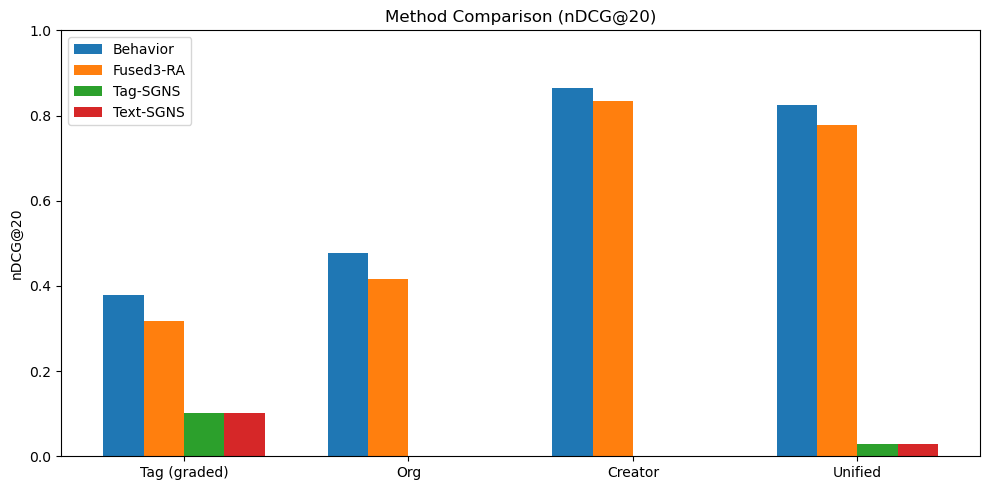

In [26]:
# =========================
# Step 10.4 · Execute: Tag→graded + Unified + 可视化
# =========================
import numpy as np, pandas as pd, json
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt

# 复用 Step 10.1 的函数：
# - build_topk_for_method(prefix, k_eval)
# - average_precision_at_k / mrr_at_k / precision_at_k / recall_at_k
# - 我们这里重写一个 nDCG（graded）的实现，IDCG 用“候选并集”近似

def _require(p: Path, desc: str):
    if not p.exists():
        raise FileNotFoundError(f"[FATAL] 缺少 {desc}: {p.as_posix()}")

for p, d in [
    (TAG_DOCS_PATH, "relevance_tag_docs.parquet"),
    (TAG_IDF_PATH,  "relevance_tag_idf.parquet"),
    (ORG_REL_PATH,  "relevance_org.parquet"),
    (CREATOR_REL_PATH, "relevance_creator.parquet"),
]:
    _require(p, d)

# ---- 载入银标与辅助表 ----
tag_docs = pd.read_parquet(TAG_DOCS_PATH, engine="fastparquet")
N = len(tag_docs)
assert (tag_docs["doc_idx"].to_numpy() == np.arange(N)).all(), "[FATAL] tag_docs 未按 0..N-1 对齐"

tag_idf_df = pd.read_parquet(TAG_IDF_PATH, engine="fastparquet")
tag2idf = dict(zip(tag_idf_df["tag"].astype(str), tag_idf_df["idf"].astype(float)))

org_df = pd.read_parquet(ORG_REL_PATH, engine="fastparquet")
creator_df = pd.read_parquet(CREATOR_REL_PATH, engine="fastparquet")
assert len(org_df)==N and len(creator_df)==N
org_ids     = org_df["org_id"].to_numpy(np.int64)
creator_ids = creator_df["creator_id"].to_numpy(np.int64)

# 文档的标签集合 & 其 IDF 总和（用于归一化）
doc_tags = [set(lst) if isinstance(lst, list) else set() for lst in tag_docs["tags"].tolist()]
doc_tag_idf_sum = np.zeros(N, dtype=np.float32)
for i, s in enumerate(doc_tags):
    if s:
        doc_tag_idf_sum[i] = np.sum([tag2idf.get(t, 0.0) for t in s], dtype=np.float32)

# 预计算 org/creator 的相关总数（Recall 分母）
def counts_by_id(arr: np.ndarray) -> np.ndarray:
    uniq, inv = np.unique(arr, return_inverse=True)
    cnt = np.bincount(inv)
    return cnt[inv]

org_cnt_all     = counts_by_id(org_ids)
creator_cnt_all = counts_by_id(creator_ids)
org_total_rel     = np.where(org_ids >= 0, np.maximum(0, org_cnt_all - 1), 0)
creator_total_rel = np.maximum(0, creator_cnt_all - 1)

# ---- 收集各方法的 Top-K 邻居 ----
method_nbr = {}
for name, prefix in METHOD_PREFIXES.items():
    nbr_idx, nbr_w = build_topk_for_method(prefix, k_eval=K_EVAL)
    method_nbr[name] = nbr_idx  # 只用索引即可

# ---- 构建每个 query 的“候选并集” ----
cand_union = []
for i in range(N):
    acc = []
    for name in METHOD_PREFIXES.keys():
        arr = method_nbr[name][i]
        acc.append(arr[arr >= 0])
    if acc:
        cu = np.unique(np.concatenate(acc))
        cu = cu[cu != i]  # 去掉自环
    else:
        cu = np.empty(0, dtype=np.int64)
    cand_union.append(cu)

# ---- 计算单对相似的增益 ----
def tag_gain(i: int, js: np.ndarray) -> np.ndarray:
    """Tag（graded）增益： sum_idf(intersection) / sum_idf(query) ∈ [0,1]，无标签则为0。"""
    if js.size == 0:
        return np.zeros(0, dtype=np.float32)
    denom = float(doc_tag_idf_sum[i])
    if denom <= 0:
        return np.zeros(js.size, dtype=np.float32)
    qi = doc_tags[i]
    gains = np.empty(js.size, dtype=np.float32)
    for k, j in enumerate(js):
        inter = qi & doc_tags[j]
        if not inter:
            gains[k] = 0.0
        else:
            gains[k] = np.sum([tag2idf.get(t, 0.0) for t in inter], dtype=np.float32) / denom
    return gains

def org_bin(i: int, js: np.ndarray) -> np.ndarray:
    if js.size == 0 or org_ids[i] < 0:
        return np.zeros(js.size, dtype=np.float32)
    return (org_ids[js] == org_ids[i]).astype(np.float32)

def creator_bin(i: int, js: np.ndarray) -> np.ndarray:
    if js.size == 0:
        return np.zeros(js.size, dtype=np.float32)
    return (creator_ids[js] == creator_ids[i]).astype(np.float32)

def unified_gain(i: int, js: np.ndarray) -> np.ndarray:
    return W_TAG * tag_gain(i, js) + W_ORG * org_bin(i, js) + W_CREATOR * creator_bin(i, js)

# ---- nDCG(graded) with candidate-union IDCG ----
def ndcg_graded_from_candidates(i: int, ranked_js: np.ndarray, gains_on_rank: np.ndarray,
                                all_js: np.ndarray, gains_all: np.ndarray) -> float:
    """对某 query：已知方法返回顺序 ranked_js 的 graded 增益，以及“候选并集”的所有候选及其增益（用于IDCG）"""
    if ranked_js.size == 0:
        return 0.0
    # DCG
    ranks = np.arange(1, ranked_js.size + 1)
    dcg = float(np.sum(gains_on_rank / np.log2(ranks + 1)))
    # IDCG：候选并集 gains_all 取前K
    if gains_all.size == 0:
        return 0.0
    top = np.sort(gains_all)[-ranked_js.size:][::-1]
    idcg = float(np.sum(top / np.log2(np.arange(1, top.size + 1) + 1)))
    return float(dcg / (idcg + 1e-12))

# ---- 二值指标在候选并集上的实现（用于 MAP/MRR/P/R 的 unified/tag 二值版）----
def binary_from_gain(g: np.ndarray) -> np.ndarray:
    return (g > 0).astype(np.int8)

def eval_suite_for_method(name: str, nbr_idx: np.ndarray) -> dict:
    """返回该方法在四个任务上的聚合指标：Tag(graded)、Org(binary)、Creator(binary)、Unified(graded + binary派生)"""
    K = nbr_idx.shape[1]
    # 预先算折扣
    disc = 1.0 / np.log2(np.arange(2, K + 2))
    idcg_tbl_bin = np.cumsum(disc)  # 二值时的IDCG表

    out = {}

    # ---- A. Tag（graded）----
    ndcg_s = map_s = mrr_s = p_s = r_s = cov = cnt = 0.0
    for i in range(N):
        if doc_tag_idf_sum[i] <= 0:  # 无标签，无从评测
            continue
        ranked = nbr_idx[i]
        ranked = ranked[ranked >= 0]
        if ranked.size == 0:
            continue
        # 本方法排名上的增益
        gains_rank = tag_gain(i, ranked)
        # 候选并集上的增益（用于IDCG）
        allc = cand_union[i]
        gains_all = tag_gain(i, allc)
        # nDCG
        ndcg_s += ndcg_graded_from_candidates(i, ranked, gains_rank, allc, gains_all)
        # 二值派生：>0 为相关
        rel_bin = binary_from_gain(gains_rank)
        # 分母（总相关数）用候选并集的二值个数，避免无限大分母
        tot_rel = int(np.sum(gains_all > 0))
        if tot_rel <= 0:
            continue
        cov += 1.0; cnt += 1.0
        # AP/MRR/P/R（binary）
        map_s += average_precision_at_k(rel_bin)
        mrr_s += mrr_at_k(rel_bin)
        p_s   += precision_at_k(rel_bin)
        r_s   += recall_at_k(rel_bin, tot_rel)

    out[f"TagG-nDCG@{K}"] = ndcg_s / max(1.0, cnt)
    out[f"TagG-MAP@{K}"]  = map_s  / max(1.0, cnt)
    out[f"TagG-MRR@{K}"]  = mrr_s  / max(1.0, cnt)
    out[f"TagG-P@{K}"]    = p_s    / max(1.0, cnt)
    out[f"TagG-R@{K}"]    = r_s    / max(1.0, cnt)
    out["TagG-Coverage"]  = cov / N

    # ---- B. Org（二值，闭式 IDCG，与 10.3 一致）----
    ndcg_s = map_s = mrr_s = p_s = r_s = cov = cnt = 0.0
    for i in range(N):
        if org_ids[i] < 0:  # 无组织
            continue
        tot_rel = int(org_total_rel[i])
        if tot_rel <= 0:
            continue
        ranked = nbr_idx[i]
        ranked = ranked[ranked >= 0]
        if ranked.size == 0:
            continue
        rels = (org_ids[ranked] == org_ids[i]).astype(np.int8)
        # nDCG
        dcg = float(np.sum(rels * disc[:ranked.size]))
        idcg = float(idcg_tbl_bin[min(K, tot_rel) - 1])
        ndcg_s += dcg / idcg
        # 其他
        map_s += average_precision_at_k(rels)
        mrr_s += mrr_at_k(rels)
        p_s   += precision_at_k(rels)
        r_s   += recall_at_k(rels, tot_rel)
        cov += 1.0; cnt += 1.0

    out[f"Org-nDCG@{K}"] = ndcg_s / max(1.0, cnt)
    out[f"Org-MAP@{K}"]  = map_s  / max(1.0, cnt)
    out[f"Org-MRR@{K}"]  = mrr_s  / max(1.0, cnt)
    out[f"Org-P@{K}"]    = p_s    / max(1.0, cnt)
    out[f"Org-R@{K}"]    = r_s    / max(1.0, cnt)
    out["Org-Coverage"]  = cov / N

    # ---- C. Creator（二值，闭式 IDCG，与 10.3 一致）----
    ndcg_s = map_s = mrr_s = p_s = r_s = cov = cnt = 0.0
    for i in range(N):
        tot_rel = int(creator_total_rel[i])
        if tot_rel <= 0:
            continue
        ranked = nbr_idx[i]
        ranked = ranked[ranked >= 0]
        if ranked.size == 0:
            continue
        rels = (creator_ids[ranked] == creator_ids[i]).astype(np.int8)
        dcg = float(np.sum(rels * disc[:ranked.size]))
        idcg = float(idcg_tbl_bin[min(K, tot_rel) - 1])
        ndcg_s += dcg / idcg

        map_s += average_precision_at_k(rels)
        mrr_s += mrr_at_k(rels)
        p_s   += precision_at_k(rels)
        r_s   += recall_at_k(rels, tot_rel)
        cov += 1.0; cnt += 1.0

    out[f"Creator-nDCG@{K}"] = ndcg_s / max(1.0, cnt)
    out[f"Creator-MAP@{K}"]  = map_s  / max(1.0, cnt)
    out[f"Creator-MRR@{K}"]  = mrr_s  / max(1.0, cnt)
    out[f"Creator-P@{K}"]    = p_s    / max(1.0, cnt)
    out[f"Creator-R@{K}"]    = r_s    / max(1.0, cnt)
    out["Creator-Coverage"]  = cov / N

    # ---- D. Unified（graded：W_tag*tag + W_org*bin + W_creator*bin）
    ndcg_s = map_s = mrr_s = p_s = r_s = cov = cnt = 0.0
    for i in range(N):
        ranked = nbr_idx[i]
        ranked = ranked[ranked >= 0]
        if ranked.size == 0:
            continue
        # 增益（本方法排名） & 候选并集上的增益（IDCG）
        gains_rank = unified_gain(i, ranked)
        allc = cand_union[i]
        gains_all = unified_gain(i, allc)
        # 如果候选里所有增益都是 0，则不可评
        if gains_all.size == 0 or np.all(gains_all <= 0):
            continue
        # nDCG（graded）
        ndcg_s += ndcg_graded_from_candidates(i, ranked, gains_rank, allc, gains_all)
        # 二值派生（>0 为相关）
        rel_bin = binary_from_gain(gains_rank)
        tot_rel = int(np.sum(gains_all > 0))
        if tot_rel <= 0:
            continue
        map_s += average_precision_at_k(rel_bin)
        mrr_s += mrr_at_k(rel_bin)
        p_s   += precision_at_k(rel_bin)
        r_s   += recall_at_k(rel_bin, tot_rel)
        cov += 1.0; cnt += 1.0

    out[f"Unified-nDCG@{K}"] = ndcg_s / max(1.0, cnt)
    out[f"Unified-MAP@{K}"]  = map_s  / max(1.0, cnt)
    out[f"Unified-MRR@{K}"]  = mrr_s  / max(1.0, cnt)
    out[f"Unified-P@{K}"]    = p_s    / max(1.0, cnt)
    out[f"Unified-R@{K}"]    = r_s    / max(1.0, cnt)
    out["Unified-Coverage"]  = cov / N

    return out

# ---- 评测并汇总 ----
rows = []
for name, prefix in METHOD_PREFIXES.items():
    res = eval_suite_for_method(name, method_nbr[name])
    row = {"method": name}; row.update(res)
    rows.append(row)
    pretty = ", ".join([f"{k}={v:.4f}" for k, v in res.items() if "Coverage" not in k])
    print(f"[RESULT-v2] {name}: {pretty}")

df_v2 = pd.DataFrame(rows)
df_v2.to_csv(OUT_CSV_V2, index=False)
print(f"\n[SAVE] {OUT_CSV_V2}")
display(df_v2.head())

# ---- 可视化：主图（nDCG@20）----
# 展示四个任务的 nDCG（TagG / Org / Creator / Unified）
tasks = [f"TagG-nDCG@{K_EVAL}", f"Org-nDCG@{K_EVAL}", f"Creator-nDCG@{K_EVAL}", f"Unified-nDCG@{K_EVAL}"]
methods = list(METHOD_PREFIXES.keys())

# 排序方法：按 Unified-nDCG 排序，突出融合优势
order = df_v2.sort_values(by=f"Unified-nDCG@{K_EVAL}", ascending=False)["method"].tolist()
x = np.arange(len(tasks))
width = 0.18

plt.figure(figsize=(10, 5))
for idx, m in enumerate(order):
    vals = [df_v2.loc[df_v2["method"]==m, t].values[0] for t in tasks]
    plt.bar(x + (idx - (len(order)-1)/2)*width, vals, width=width, label=m)

plt.xticks(x, ["Tag (graded)", "Org", "Creator", "Unified"])
plt.ylabel("nDCG@20")
plt.ylim(0, 1.0)
plt.title("Method Comparison (nDCG@20)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_FIG, dpi=150)
print(f"[FIG] saved -> {OUT_FIG}")


In [27]:
# =========================
# Step 10.4A · Params (revised): Tag-PPMI Cosine & Engagement-Cosine baselines
# =========================
from pathlib import Path
TMP_DIR = Path("./tmp").resolve()

# —— 通用设置 ——
K_TOPK = 50                 # 构图每行最多保留 K 条边
PART_EDGES = 2_000_000      # 分片写出边数
K_EVAL = 20                 # 评测截断@K

# —— 统一指标权重 ——
W_TAG = 0.6
W_ORG = 0.1
W_CRE = 0.3

# —— 输入（已有产物） ——
DT_PPMI_PATH  = TMP_DIR / "DT_ppmi.parquet"                 # D–T (PPMI) 稀疏：row, col, val
S_ENG_TOPK_MANIFEST = TMP_DIR / "S_eng_topk_k50_manifest.json"  # 行内 topK（行为特征 FAISS 已算好）

# —— 输出前缀 ——
PPMI_TOPK_PREFIX   = "S_tagppmi_topk"      # 本步先算“topk”，再统一对称化→symrow
PPMI_SYMROW_PREFIX = "S_tagppmi_symrow"
ENG_SYMROW_PREFIX  = "S_engcos_symrow"     # 从 S_eng_topk 派生

# —— 结果文件 ——
OUT_BASELINES_A = TMP_DIR / "metrics_baselines_A.csv"          # 本步新结果
OUT_MAIN        = TMP_DIR / "metrics_main.csv"                 # 之前主方法结果（若存在则追加统一指标列）
OUT_MAIN_UNI    = TMP_DIR / "metrics_main_with_unified.csv"    # 追加统一指标后的拷贝

print(f"[Env] TMP_DIR={TMP_DIR}")
print(f"[Eval] K_EVAL={K_EVAL}  Weights: Tag={W_TAG}, Org={W_ORG}, Creator={W_CRE}")


[Env] TMP_DIR=/home/koyo/workspace/recsys/tmp
[Eval] K_EVAL=20  Weights: Tag=0.6, Org=0.1, Creator=0.3


In [28]:
# =========================
# Step 10.4A · Execute (revised): baselines + unified metrics (coverage-weighted)
# =========================
import json
import numpy as np
import pandas as pd
from collections import defaultdict
from pathlib import Path

import torch

# ---- 复用 10.1/10.3 的工具：build_topk_for_method、指标函数 ----
# 若当前内核重启，请先执行你之前的“工具定义单元”。

def _require(p: Path, desc: str):
    if not p.exists():
        raise FileNotFoundError(f"[FATAL] 缺少 {desc}: {p.as_posix()}")

# ========== A) 基线1：Tag-PPMI Cosine ==========
# 思路：用 DT_ppmi 的行向量做余弦相似；为避免全库 O(N^2)，用“top-T 标签 + 候选上限”近似。
# 本版尽可能用 PyTorch（GPU 可用则放 CUDA），在候选评分与 topk 选择阶段做张量化。

_require(DT_PPMI_PATH, "DT_ppmi.parquet")
DT = pd.read_parquet(DT_PPMI_PATH, engine="fastparquet")  # columns: row, col, val
N = int(DT["row"].max()) + 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[PPMI] device={device.type}  N={N:,}")

# 每个 doc 的 L2 范数
doc_norm = DT.assign(v2=DT["val"]**2).groupby("row")["v2"].sum().reindex(range(N), fill_value=0).to_numpy()
doc_norm = np.sqrt(np.maximum(doc_norm, 1e-12)).astype(np.float32)
doc_norm_t = torch.from_numpy(doc_norm).to(device, non_blocking=True)

# 每个标签的倒排（按 val 降序），并统计 df
grp_by_col = DT.groupby("col")
post_rows = {}
post_vals = {}
col_df = {}
for col, g in grp_by_col:
    a = g.sort_values("val", ascending=False)
    post_rows[int(col)] = a["row"].to_numpy(np.int32, copy=True)
    post_vals[int(col)] = a["val"].to_numpy(np.float32, copy=True)
    col_df[int(col)] = len(a)

# 超参数（候选控制）
T_PER_DOC   = 3      # 每 doc 使用的最强标签数
R_CAND_EACH = 200    # 每标签的候选上限
DF_CAP      = 10000  # 过热标签阈值（跳过）
BATCH_ITERS = 1      # 单 doc 评估（候选分散，batch 并不稳定，这里保持逐 doc）

# 为每个 doc 预取 top-T 标签（过滤过热标签）
DT_sorted = DT.sort_values(["row", "val"], ascending=[True, False])
topT = DT_sorted.groupby("row").head(T_PER_DOC)
top_map = defaultdict(list)
for r, g in topT.groupby("row"):
    lst = []
    for _, row in g.iterrows():
        c = int(row["col"]); v = float(row["val"])
        if col_df.get(c, 0) <= DF_CAP:
            lst.append((c, v))
    top_map[int(r)] = lst

# 候选累计 & 余弦相似计算（用 torch）
edge_rows, edge_cols, edge_vals = [], [], []
for i in range(N):
    if (i % 50_000) == 0:
        print(f"[PPMI] progressed {i:,}/{N:,}")
    anchors = top_map.get(i, [])
    if not anchors:
        continue

    # 累计 dot：neighbor -> sum_t (w_i,t * w_j,t)
    # 为减少 Python 循环，先拼接该 doc 的所有候选，再按 nb 聚合
    nb_list = []
    sc_list = []
    for (c, w_ic) in anchors:
        rows_c = post_rows[c][:R_CAND_EACH]
        vals_c = post_vals[c][:R_CAND_EACH]
        if rows_c.size == 0:
            continue
        # 跳过 self
        mask = rows_c != i
        nb = rows_c[mask]
        sc = (w_ic * vals_c[mask]).astype(np.float32)
        if nb.size:
            nb_list.append(nb)
            sc_list.append(sc)

    if not nb_list:
        continue

    nb_all = np.concatenate(nb_list)
    sc_all = np.concatenate(sc_list)
    # 聚合（np.add.at 比 dict 累加快）
    # 先对 nb_all 做 unique
    uniq_nb, inv_idx = np.unique(nb_all, return_inverse=True)
    dot_acc = np.zeros(uniq_nb.size, dtype=np.float32)
    np.add.at(dot_acc, inv_idx, sc_all)

    # sim = dot / (||i|| * ||j||)
    with torch.no_grad():
        ni = doc_norm_t[i].clamp_min_(1e-12)
        nb_t = torch.from_numpy(uniq_nb).to(device, non_blocking=True)
        nj = doc_norm_t.index_select(0, nb_t).clamp_min_(1e-12)
        dot_t = torch.from_numpy(dot_acc).to(device, non_blocking=True)
        sim_t = dot_t / (ni * nj)

        # 选 top-K
        if sim_t.numel() > K_TOPK:
            sim_topk, idx_topk = torch.topk(sim_t, K_TOPK, largest=True, sorted=True)
            js = nb_t[idx_topk].to("cpu").numpy().astype(np.int32)
            ss = sim_topk.to("cpu").numpy().astype(np.float32)
        else:
            # 全量排序
            ords = torch.argsort(sim_t, descending=True)
            js = nb_t[ords].to("cpu").numpy().astype(np.int32)
            ss = sim_t[ords].to("cpu").numpy().astype(np.float32)

    edge_rows.append(np.full(js.size, i, dtype=np.int32))
    edge_cols.append(js)
    edge_vals.append(ss)

if edge_rows:
    rows = np.concatenate(edge_rows)
    cols = np.concatenate(edge_cols)
    vals = np.concatenate(edge_vals)
else:
    rows = np.zeros(0, dtype=np.int32)
    cols = np.zeros(0, dtype=np.int32)
    vals = np.zeros(0, dtype=np.float32)

print(f"[PPMI] built topK edges = {len(vals):,}")

def save_topk(prefix: str, rows: np.ndarray, cols: np.ndarray, vals: np.ndarray, k: int):
    total = len(vals)
    parts = []
    if total == 0:
        raise RuntimeError("[FATAL] no edges")
    start = 0; pid = 0
    while start < total:
        end = min(total, start + PART_EDGES)
        df = pd.DataFrame({"row": rows[start:end], "col": cols[start:end], "val": vals[start:end]})
        fn = f"{prefix}_k{k:02d}_part{pid:04d}.parquet"
        df.to_parquet(TMP_DIR / fn, engine="fastparquet", index=False)
        parts.append(fn)
        print(f"[SAVE] {fn} edges={end-start:,}")
        start = end; pid += 1
    man = {"nodes": int(N), "k": int(k), "parts": parts, "nnz": int(total)}
    (TMP_DIR / f"{prefix}_k{k:02d}_manifest.json").write_text(json.dumps(man, ensure_ascii=False, indent=2))
    print(f"[MANIFEST] {prefix}_k{k:02d}_manifest.json  nnz={total:,}")

save_topk(PPMI_TOPK_PREFIX, rows, cols, vals, K_TOPK)

# 对称化 + 行归一，写出 *_symrow_*
def symrow_from_topk(prefix_in: str, prefix_out: str, k: int):
    man = json.loads((TMP_DIR / f"{prefix_in}_k{k:02d}_manifest.json").read_text())
    parts = [TMP_DIR / p for p in man["parts"]]
    adj = defaultdict(dict)
    for i, fp in enumerate(parts, 1):
        df = pd.read_parquet(fp, engine="fastparquet")
        r = df["row"].to_numpy(np.int32)
        c = df["col"].to_numpy(np.int32)
        v = df["val"].to_numpy(np.float32)
        for rr, cc, vv in zip(r, c, v):
            d = adj[rr]; d[cc] = d.get(cc, 0.0) + float(vv)
            dT = adj[cc]; dT[rr] = dT.get(rr, 0.0) + float(vv)
        if (i % 4) == 0 or i == len(parts):
            print(f"[LOAD] {i}/{len(parts)} parts loaded for {prefix_in}")

    rows_out, cols_out, vals_out = [], [], []
    for rr in range(N):
        d = adj.get(rr, {})
        if not d:
            continue
        cols_r = np.fromiter(d.keys(), dtype=np.int32)
        vals_r = np.fromiter(d.values(), dtype=np.float32)
        if cols_r.size > k:
            part = np.argpartition(vals_r, -k)[-k:]
            sel = part[np.argsort(-vals_r[part])]
            cols_r = cols_r[sel]; vals_r = vals_r[sel]
        else:
            ords = np.argsort(-vals_r)
            cols_r = cols_r[ords]; vals_r = vals_r[ords]
        s = float(vals_r.sum())
        if s > 0:
            vals_r = (vals_r / s).astype(np.float32)
        rows_out.append(np.full(cols_r.size, rr, dtype=np.int32))
        cols_out.append(cols_r.astype(np.int32))
        vals_out.append(vals_r.astype(np.float32))

    rows_out = np.concatenate(rows_out) if rows_out else np.zeros(0, dtype=np.int32)
    cols_out = np.concatenate(cols_out) if cols_out else np.zeros(0, dtype=np.int32)
    vals_out = np.concatenate(vals_out) if vals_out else np.zeros(0, dtype=np.float32)

    save_topk(prefix_out, rows_out, cols_out, vals_out, k)

# 对称化 Tag-PPMI
symrow_from_topk(PPMI_TOPK_PREFIX, PPMI_SYMROW_PREFIX, K_TOPK)

# ========== B) 基线2：Engagement-Cosine（从 S_eng_topk → symrow） ==========
_require(S_ENG_TOPK_MANIFEST, "S_eng_topk_k50_manifest.json")
symrow_from_topk("S_eng_topk", ENG_SYMROW_PREFIX, K_TOPK)

# ========== C) 评测二个基线 + 统一指标（含覆盖率加权） ==========
METHOD_PREFIXES = {
    "Tag-PPMI-Cos":   PPMI_SYMROW_PREFIX,
    "Eng-Cosine":     ENG_SYMROW_PREFIX,
}

rows = []
for name, prefix in METHOD_PREFIXES.items():
    res = evaluate_method(prefix, name, k_eval=K_EVAL)  # 返回含 Coverage 的字典
    row = {"method": name}; row.update(res)
    rows.append(row)
    pretty = ", ".join([f"{k}={v:.4f}" for k, v in res.items() if "Coverage" not in k])
    print(f"[RESULT] {name}: {pretty}")

df_out = pd.DataFrame(rows)

# —— 统一指标（不加权 & 覆盖率加权） ——
df_out["Unified@nDCG20"] = (
    W_TAG * df_out["Tag-nDCG@20"] +
    W_ORG * df_out["Org-nDCG@20"] +
    W_CRE * df_out["Creator-nDCG@20"]
)

# 覆盖率加权版本
num = (
    W_TAG * df_out["Tag-Coverage"] * df_out["Tag-nDCG@20"] +
    W_ORG * df_out["Org-Coverage"] * df_out["Org-nDCG@20"] +
    W_CRE * df_out["Creator-Coverage"] * df_out["Creator-nDCG@20"]
)
den = (
    W_TAG * df_out["Tag-Coverage"] +
    W_ORG * df_out["Org-Coverage"] +
    W_CRE * df_out["Creator-Coverage"]
).replace(0, np.finfo(float).eps)
df_out["Unified_cov@nDCG20"] = (num / den)

# 保存本步结果
df_out.to_csv(OUT_BASELINES_A, index=False)
print(f"\n[SAVE] {OUT_BASELINES_A}")

# —— 可选：给已有的 metrics_main.csv 追加统一指标列（若文件存在） ——
if OUT_MAIN.exists():
    df_main = pd.read_csv(OUT_MAIN)
    for col in ["Tag-nDCG@20","Org-nDCG@20","Creator-nDCG@20",
                "Tag-Coverage","Org-Coverage","Creator-Coverage"]:
        if col not in df_main.columns:
            print(f"[WARN] main file missing column: {col}  -> skip adding unified columns")
            break
    else:
        df_main["Unified@nDCG20"] = (
            W_TAG * df_main["Tag-nDCG@20"] +
            W_ORG * df_main["Org-nDCG@20"] +
            W_CRE * df_main["Creator-nDCG@20"]
        )
        num_m = (
            W_TAG * df_main["Tag-Coverage"] * df_main["Tag-nDCG@20"] +
            W_ORG * df_main["Org-Coverage"] * df_main["Org-nDCG@20"] +
            W_CRE * df_main["Creator-Coverage"] * df_main["Creator-nDCG@20"]
        )
        den_m = (
            W_TAG * df_main["Tag-Coverage"] +
            W_ORG * df_main["Org-Coverage"] +
            W_CRE * df_main["Creator-Coverage"]
        ).replace(0, np.finfo(float).eps)
        df_main["Unified_cov@nDCG20"] = (num_m / den_m)
        df_main.to_csv(OUT_MAIN_UNI, index=False)
        print(f"[SAVE] {OUT_MAIN_UNI}  (main results with unified metrics)")
df_out


[PPMI] device=cuda  N=521,733
[PPMI] progressed 0/521,733
[PPMI] progressed 50,000/521,733
[PPMI] progressed 100,000/521,733
[PPMI] progressed 150,000/521,733
[PPMI] progressed 200,000/521,733
[PPMI] progressed 250,000/521,733
[PPMI] progressed 300,000/521,733
[PPMI] progressed 350,000/521,733
[PPMI] progressed 400,000/521,733
[PPMI] progressed 450,000/521,733
[PPMI] progressed 500,000/521,733
[PPMI] built topK edges = 7,666,761
[SAVE] S_tagppmi_topk_k50_part0000.parquet edges=2,000,000
[SAVE] S_tagppmi_topk_k50_part0001.parquet edges=2,000,000
[SAVE] S_tagppmi_topk_k50_part0002.parquet edges=2,000,000
[SAVE] S_tagppmi_topk_k50_part0003.parquet edges=1,666,761
[MANIFEST] S_tagppmi_topk_k50_manifest.json  nnz=7,666,761
[LOAD] 4/4 parts loaded for S_tagppmi_topk
[SAVE] S_tagppmi_symrow_k50_part0000.parquet edges=2,000,000
[SAVE] S_tagppmi_symrow_k50_part0001.parquet edges=2,000,000
[SAVE] S_tagppmi_symrow_k50_part0002.parquet edges=2,000,000
[SAVE] S_tagppmi_symrow_k50_part0003.parquet e

,method,Tag-nDCG@20,Tag-MAP@20,Tag-MRR@20,Tag-P@20,Tag-R@20,Tag-Coverage,Org-nDCG@20,Org-MAP@20,Org-MRR@20,...,Org-R@20,Org-Coverage,Creator-nDCG@20,Creator-MAP@20,Creator-MRR@20,Creator-P@20,Creator-R@20,Creator-Coverage,Unified@nDCG20,Unified_cov@nDCG20
0,Tag-PPMI-Cos,0.714654,0.714663,0.714663,0.714641,0.005114,0.411293,0.140373,0.161631,0.180795,...,0.021564,0.004504,0.009744,0.011100,0.011587,0.009039,0.001956,0.775899,0.445753,0.372275
1,Eng-Cosine,0.068933,0.129683,0.155417,0.068490,0.000110,0.411293,0.051849,0.107817,0.126435,...,0.012831,0.004504,0.008131,0.014266,0.014606,0.007619,0.001688,0.775899,0.048984,0.039432


In [31]:
# =========================
# Step 10.4B · Params: Text-BM25-Cos & Text-Binary-Cos
# =========================
from pathlib import Path

TMP_DIR = Path("./tmp").resolve()

# 构图控制
K_TOPK       = 50          # 每行保留近邻数（与前面一致）
PART_EDGES   = 2_000_000   # 分片落盘大小
K_EVAL       = 20          # 评测截断

# 候选生成控制（越大越准、越慢）
T_PER_DOC    = 5           # 每文档选择的最强 anchor 词数
R_CAND_EACH  = 200         # 每个 anchor 词召回的候选文档上限
DF_CAP       = 20000       # 跳过超级高频的词（df 上限）

# 统一指标权重
W_TAG, W_ORG, W_CRE = 0.6, 0.1, 0.3

# 输入产物
DW_BM25_PATH   = TMP_DIR / "DW_bm25.parquet"     # 文档-词 BM25 稀疏 COO: row,col,val
TEXT_VOCAB     = TMP_DIR / "text_vocab.parquet"  # 词表（含 df 或 idf）

# 输出前缀
BM25_TOPK_PREFIX   = "S_textbm25_topk"
BM25_SYMROW_PREFIX = "S_textbm25_symrow"
BIN_SYMROW_PREFIX  = "S_textbin_symrow"

OUT_BASELINES_B    = TMP_DIR / "metrics_baselines_B.csv"

print(f"[Env] TMP_DIR={TMP_DIR}")
print(f"[Params] K_TOPK={K_TOPK}, T_PER_DOC={T_PER_DOC}, R_CAND_EACH={R_CAND_EACH}, DF_CAP={DF_CAP}, K_EVAL={K_EVAL}")


[Env] TMP_DIR=/home/koyo/workspace/recsys/tmp
[Params] K_TOPK=50, T_PER_DOC=5, R_CAND_EACH=200, DF_CAP=20000, K_EVAL=20


In [33]:
# =========================
# Step 10.4B · Execute (robust, vocab-free IDF)
# =========================
import json, math
import numpy as np
import pandas as pd
from collections import defaultdict
from pathlib import Path
import torch

def _require(p: Path, name: str):
    if not p.exists():
        raise FileNotFoundError(f"[FATAL] missing {name}: {p.as_posix()}")

# 1) 读取 BM25 稀疏矩阵（COO）
_require(DW_BM25_PATH, "DW_bm25.parquet")
DW = pd.read_parquet(DW_BM25_PATH, engine="fastparquet")  # columns: row,col,val
if not {"row","col","val"}.issubset(set(DW.columns)):
    raise ValueError(f"[FATAL] DW_bm25.parquet 必须包含列 ['row','col','val']，当前列={DW.columns.tolist()}")

N_docs = int(DW["row"].max()) + 1
N_terms = int(DW["col"].max()) + 1
print(f"[BM25] N_docs={N_docs:,}, N_terms≈{N_terms:,}, nnz={len(DW):,}")

# 2) 直接用 DW 计算 df 与 idf（不依赖 text_vocab.parquet 的列名）
#    idf = log((N+1)/(df+1))，避免除零
df_series = DW.groupby("col")["row"].count()        # 每个 term 出现的文档数
idf_series = np.log((N_docs + 1) / (df_series + 1)) # numpy 向量
idf_map = dict(zip(df_series.index.astype(int), idf_series.astype(float)))
print(f"[IDF] computed from DW: terms with df>0 = {len(idf_map):,}")

# 3) 预计算：每文档范数（BM25 与 Binary）
doc_norm_bm25 = DW.assign(v2=DW["val"]**2).groupby("row")["v2"].sum().reindex(range(N_docs), fill_value=0).to_numpy()
doc_norm_bm25 = np.sqrt(np.maximum(doc_norm_bm25, 1e-12)).astype(np.float32)

doc_deg_bin = DW.groupby("row")["col"].count().reindex(range(N_docs), fill_value=0).to_numpy().astype(np.int32)
doc_norm_bin = np.sqrt(np.maximum(doc_deg_bin, 1)).astype(np.float32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
doc_norm_bm25_t = torch.from_numpy(doc_norm_bm25).to(device, non_blocking=True)
doc_norm_bin_t  = torch.from_numpy(doc_norm_bin ).to(device, non_blocking=True)
print(f"[Device] {device.type}")

# 4) 倒排（按 BM25 降序），并为每文档挑选 top-T anchor 词（BM25 * idf 作为优先级）
grp_by_col = DW.groupby("col")
post_rows = {}
post_vals = {}
df_col = {}
for c, g in grp_by_col:
    a = g.sort_values("val", ascending=False)
    post_rows[int(c)] = a["row"].to_numpy(np.int32, copy=True)
    post_vals[int(c)] = a["val"].to_numpy(np.float32, copy=True)
    df_col[int(c)] = len(a)

DW_sorted = DW.sort_values(["row","val"], ascending=[True, False])

def pick_doc_anchors(row_group, t_per_doc=T_PER_DOC):
    if row_group.empty:
        return row_group
    top = row_group.head(t_per_doc).copy()
    # 优先级 = BM25 * idf（若该 term 未在 idf_map 中，取 1.0）
    prio = []
    cc = top["col"].to_numpy(np.int64)
    vv = top["val"].to_numpy(np.float32)
    for c, v in zip(cc, vv):
        prio.append(v * float(idf_map.get(int(c), 1.0)))
    top["prio"] = prio
    top = top.sort_values("prio", ascending=False)
    return top

topT = DW_sorted.groupby("row", group_keys=False).apply(lambda g: pick_doc_anchors(g, T_PER_DOC))
top_map = defaultdict(list)
for r, g in topT.groupby("row"):
    lst = []
    for _, w in g.iterrows():
        c = int(w["col"]); v = float(w["val"])
        if df_col.get(c, 0) <= DF_CAP:
            lst.append((c, v))
    top_map[int(r)] = lst

print("[Anchors] ready.")

# 5) 通用构图：BM25 余弦 / Binary 余弦（均采用 anchor 召回 + top-K）
PART_EDGES = PART_EDGES  # 使用参数单元中的值

def build_topk(prefix_out: str, score_mode: str):
    """
    score_mode: 'bm25cos' 或 'binarycos'
    """
    rows_all, cols_all, vals_all = [], [], []
    for i in range(N_docs):
        if (i % 50_000) == 0:
            print(f"[{score_mode}] progressed {i:,}/{N_docs:,}")
        anchors = top_map.get(i, [])
        if not anchors:
            continue

        nb_list = []
        sc_list = []  # 仅 bm25cos 用
        for (c, w_ic) in anchors:
            r = post_rows[c][:R_CAND_EACH]
            v = post_vals[c][:R_CAND_EACH]
            if r.size == 0:
                continue
            mask = r != i
            rr = r[mask]
            vv = v[mask]
            if rr.size == 0:
                continue
            nb_list.append(rr)
            if score_mode == "bm25cos":
                sc_list.append((w_ic * vv).astype(np.float32))

        if not nb_list:
            continue

        nb_all = np.concatenate(nb_list)

        if score_mode == "bm25cos":
            sc_all = np.concatenate(sc_list)
            uniq_nb, inv_idx = np.unique(nb_all, return_inverse=True)
            dot_acc = np.zeros(uniq_nb.size, dtype=np.float32)
            np.add.at(dot_acc, inv_idx, sc_all)

            with torch.no_grad():
                ni = doc_norm_bm25_t[i].clamp_min_(1e-12)
                nb_t = torch.from_numpy(uniq_nb).to(device, non_blocking=True)
                nj = doc_norm_bm25_t.index_select(0, nb_t).clamp_min_(1e-12)
                dot_t = torch.from_numpy(dot_acc).to(device, non_blocking=True)
                sim_t = dot_t / (ni * nj)
        else:
            # binary 余弦：approx 重合 anchor 词数 / sqrt(deg_i * deg_j)
            uniq_nb, cnts = np.unique(nb_all, return_counts=True)
            with torch.no_grad():
                ni = doc_norm_bin_t[i].clamp_min_(1.0)
                nb_t = torch.from_numpy(uniq_nb).to(device, non_blocking=True)
                nj = doc_norm_bin_t.index_select(0, nb_t).clamp_min_(1.0)
                overlap = torch.from_numpy(cnts.astype(np.float32)).to(device, non_blocking=True)
                sim_t = overlap / (ni * nj)

        # top-K
        if sim_t.numel() > K_TOPK:
            sim_topk, idx_topk = torch.topk(sim_t, K_TOPK, largest=True, sorted=True)
            js = nb_t[idx_topk].to("cpu").numpy().astype(np.int32)
            ss = sim_topk.to("cpu").numpy().astype(np.float32)
        else:
            ords = torch.argsort(sim_t, descending=True)
            js = nb_t[ords].to("cpu").numpy().astype(np.int32)
            ss = sim_t[ords].to("cpu").numpy().astype(np.float32)

        rows_all.append(np.full(js.size, i, dtype=np.int32))
        cols_all.append(js)
        vals_all.append(ss)

    if rows_all:
        rows = np.concatenate(rows_all)
        cols = np.concatenate(cols_all)
        vals = np.concatenate(vals_all)
    else:
        rows = np.zeros(0, dtype=np.int32)
        cols = np.zeros(0, dtype=np.int32)
        vals = np.zeros(0, dtype=np.float32)

    # 分片 + manifest
    total = len(vals)
    parts = []
    start = 0; pid = 0
    while start < total:
        end = min(total, start + PART_EDGES)
        df = pd.DataFrame({"row": rows[start:end], "col": cols[start:end], "val": vals[start:end]})
        fn = f"{prefix_out}_k{K_TOPK:02d}_part{pid:04d}.parquet"
        df.to_parquet(TMP_DIR / fn, engine="fastparquet", index=False)
        parts.append(fn)
        print(f"[SAVE] {fn} edges={end-start:,}")
        start = end; pid += 1
    man = {"nodes": int(N_docs), "k": int(K_TOPK), "parts": parts, "nnz": int(total)}
    (TMP_DIR / f"{prefix_out}_k{K_TOPK:02d}_manifest.json").write_text(json.dumps(man, ensure_ascii=False, indent=2))
    print(f"[MANIFEST] {prefix_out}_k{K_TOPK:02d}_manifest.json  nnz={total:,}")

def symrow_from_topk(prefix_in: str, prefix_out: str):
    man = json.loads((TMP_DIR / f"{prefix_in}_k{K_TOPK:02d}_manifest.json").read_text())
    parts = [TMP_DIR / p for p in man["parts"]]
    adj = defaultdict(dict)
    for i, fp in enumerate(parts, 1):
        df = pd.read_parquet(fp, engine="fastparquet")
        r = df["row"].to_numpy(np.int32)
        c = df["col"].to_numpy(np.int32)
        v = df["val"].to_numpy(np.float32)
        for rr, cc, vv in zip(r, c, v):
            d = adj[rr]; d[cc] = d.get(cc, 0.0) + float(vv)
            dt = adj[cc]; dt[rr] = dt.get(rr, 0.0) + float(vv)
        if (i % 4) == 0 or i == len(parts):
            print(f"[LOAD] {i}/{len(parts)} parts loaded for {prefix_in}")

    rows_o, cols_o, vals_o = [], [], []
    for r in range(N_docs):
        d = adj.get(r, {})
        if not d:
            continue
        cols_r = np.fromiter(d.keys(), dtype=np.int32)
        vals_r = np.fromiter(d.values(), dtype=np.float32)
        if cols_r.size > K_TOPK:
            part = np.argpartition(vals_r, -K_TOPK)[-K_TOPK:]
            sel = part[np.argsort(-vals_r[part])]
            cols_r = cols_r[sel]; vals_r = vals_r[sel]
        else:
            ords = np.argsort(-vals_r)
            cols_r = cols_r[ords]; vals_r = vals_r[ords]
        s = float(vals_r.sum())
        if s > 0:
            vals_r = (vals_r / s).astype(np.float32)
        rows_o.append(np.full(cols_r.size, r, dtype=np.int32))
        cols_o.append(cols_r.astype(np.int32))
        vals_o.append(vals_r.astype(np.float32))

    rows_o = np.concatenate(rows_o) if rows_o else np.zeros(0, dtype=np.int32)
    cols_o = np.concatenate(cols_o) if cols_o else np.zeros(0, dtype=np.int32)
    vals_o = np.concatenate(vals_o) if vals_o else np.zeros(0, dtype=np.float32)

    # 保存
    total = len(vals_o); parts = []
    start = 0; pid = 0
    while start < total:
        end = min(total, start + PART_EDGES)
        dfp = pd.DataFrame({"row": rows_o[start:end], "col": cols_o[start:end], "val": vals_o[start:end]})
        fn = f"{prefix_out}_k{K_TOPK:02d}_part{pid:04d}.parquet"
        dfp.to_parquet(TMP_DIR / fn, engine="fastparquet", index=False)
        parts.append(fn)
        print(f"[SAVE] {fn} edges={end-start:,}")
        start = end; pid += 1
    man_o = {"nodes": int(N_docs), "k": int(K_TOPK), "parts": parts, "nnz": int(total)}
    (TMP_DIR / f"{prefix_out}_k{K_TOPK:02d}_manifest.json").write_text(json.dumps(man_o, ensure_ascii=False, indent=2))
    print(f"[MANIFEST] {prefix_out}_k{K_TOPK:02d}_manifest.json  nnz={total:,}")

# 6) 构建 Text-BM25-Cos
build_topk(BM25_TOPK_PREFIX, "bm25cos")
symrow_from_topk(BM25_TOPK_PREFIX, BM25_SYMROW_PREFIX)

# 7) 构建 Text-Binary-Cos
build_topk("S_textbin_topk", "binarycos")
symrow_from_topk("S_textbin_topk", BIN_SYMROW_PREFIX)

# 8) 评测 + 统一指标（覆盖率加权）
METHODS = {
    "Text-BM25-Cos": BM25_SYMROW_PREFIX,
    "Text-Binary-Cos": BIN_SYMROW_PREFIX,
}
rows = []
for name, pref in METHODS.items():
    res = evaluate_method(pref, name, k_eval=K_EVAL)
    row = {"method": name}; row.update(res)
    rows.append(row)
    print("[RESULT]", name, {k: round(v,4) for k,v in res.items() if "Coverage" not in k})

dfb = pd.DataFrame(rows)

# 统一指标（固定权与覆盖率加权）
dfb["Unified@nDCG20"] = (W_TAG*dfb["Tag-nDCG@20"] + W_ORG*dfb["Org-nDCG@20"] + W_CRE*dfb["Creator-nDCG@20"])
num = (W_TAG*dfb["Tag-Coverage"]*dfb["Tag-nDCG@20"]
     + W_ORG*dfb["Org-Coverage"]*dfb["Org-nDCG@20"]
     + W_CRE*dfb["Creator-Coverage"]*dfb["Creator-nDCG@20"])
den = (W_TAG*dfb["Tag-Coverage"] + W_ORG*dfb["Org-Coverage"] + W_CRE*dfb["Creator-Coverage"]).replace(0, np.finfo(float).eps)
dfb["Unified_cov@nDCG20"] = (num/den)

dfb.to_csv(OUT_BASELINES_B, index=False)
print(f"[SAVE] {OUT_BASELINES_B}")
dfb.sort_values("Unified_cov@nDCG20", ascending=False)


[BM25] N_docs=521,734, N_terms≈5,754, nnz=8,140,467
[IDF] computed from DW: terms with df>0 = 5,754
[Device] cuda


/tmp/ipykernel_1108/3645666759.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topT = DW_sorted.groupby("row", group_keys=False).apply(lambda g: pick_doc_anchors(g, T_PER_DOC))


[Anchors] ready.
[bm25cos] progressed 0/521,734
[bm25cos] progressed 50,000/521,734
[bm25cos] progressed 100,000/521,734
[bm25cos] progressed 150,000/521,734
[bm25cos] progressed 200,000/521,734
[bm25cos] progressed 250,000/521,734
[bm25cos] progressed 300,000/521,734
[bm25cos] progressed 350,000/521,734
[bm25cos] progressed 400,000/521,734
[bm25cos] progressed 450,000/521,734
[bm25cos] progressed 500,000/521,734
[SAVE] S_textbm25_topk_k50_part0000.parquet edges=2,000,000
[SAVE] S_textbm25_topk_k50_part0001.parquet edges=2,000,000
[SAVE] S_textbm25_topk_k50_part0002.parquet edges=2,000,000
[SAVE] S_textbm25_topk_k50_part0003.parquet edges=2,000,000
[SAVE] S_textbm25_topk_k50_part0004.parquet edges=2,000,000
[SAVE] S_textbm25_topk_k50_part0005.parquet edges=2,000,000
[SAVE] S_textbm25_topk_k50_part0006.parquet edges=2,000,000
[SAVE] S_textbm25_topk_k50_part0007.parquet edges=2,000,000
[SAVE] S_textbm25_topk_k50_part0008.parquet edges=2,000,000
[SAVE] S_textbm25_topk_k50_part0009.parquet

,method,Tag-nDCG@20,Tag-MAP@20,Tag-MRR@20,Tag-P@20,Tag-R@20,Tag-Coverage,Org-nDCG@20,Org-MAP@20,Org-MRR@20,...,Org-R@20,Org-Coverage,Creator-nDCG@20,Creator-MAP@20,Creator-MRR@20,Creator-P@20,Creator-R@20,Creator-Coverage,Unified@nDCG20,Unified_cov@nDCG20
0,Text-BM25-Cos,0.180745,0.248619,0.276584,0.178662,0.001088,0.411293,0.142515,0.167544,0.151409,...,0.040914,0.004504,0.036081,0.054284,0.055565,0.02513,0.020461,0.775899,0.133523,0.110556
1,Text-Binary-Cos,0.154114,0.224072,0.260034,0.150667,0.000844,0.411293,0.007065,0.016710,0.017416,...,0.002903,0.004504,0.024866,0.041049,0.042739,0.01635,0.014549,0.775899,0.100635,0.091298


In [ ]:
# =========================
# Step 10.4C · Params: RRF & CombSUM fusion of non-embedding baselines
# =========================
from pathlib import Path

TMP_DIR = Path("./tmp").resolve()

# 输入前缀（已存在）
PREF_TAGPPMI = "S_tagppmi_symrow"
PREF_TEXTBM25 = "S_textbm25_symrow"
PREF_ENGCOS  = "S_engcos_symrow"

# 输出前缀
PREF_RRF     = "S_rrf_symrow"
PREF_COMBSUM = "S_combsum_symrow"

# 通用设置
K_TOPK       = 50
PART_EDGES   = 2_000_000
K_EVAL       = 20

# RRF 超参
RRF_K0       = 60  # 典型取值 60；越大越平滑

# CombSUM 权重（等权）
W_TAGPPMI, W_TEXTBM25, W_ENG = 1/3, 1/3, 1/3

# 统一指标权重
W_TAG, W_ORG, W_CRE = 0.6, 0.1, 0.3

OUT_FUSION = TMP_DIR / "metrics_fusion_baselines.csv"
print(f"[Env] TMP_DIR={TMP_DIR}")


[Env] TMP_DIR=/home/koyo/workspace/recsys/tmp


In [37]:
# =========================
# Step 10.4C · Execute (robust loader with unified N_target)
# =========================
import json
import numpy as np
import pandas as pd
from pathlib import Path

def _manifest(prefix: str):
    mpath = TMP_DIR / f"{prefix}_k{K_TOPK:02d}_manifest.json"
    if not mpath.exists():
        raise FileNotFoundError(f"[FATAL] manifest not found: {mpath}")
    man = json.loads(mpath.read_text())
    parts = [TMP_DIR / p for p in man["parts"]]
    nodes = int(man.get("nodes", 0))
    return nodes, parts

def _max_row_in_parts(parts):
    mr = -1
    for i, fp in enumerate(parts, 1):
        r = pd.read_parquet(fp, engine="fastparquet", columns=["row"])["row"].to_numpy()
        if r.size:
            mr = max(mr, int(r.max()))
        if (i % 4) == 0 or i == len(parts):
            print(f"[SCAN] {i}/{len(parts)} parts scanned, max_row={mr}")
    return mr

# 0) 发现统一节点数 N_target（优先 index_map / fused3）
cand_N = []

idx_map = TMP_DIR / "index_map.parquet"
if idx_map.exists():
    im = pd.read_parquet(idx_map, engine="fastparquet", columns=["doc_idx"])
    N_from_index = int(im["doc_idx"].max()) + 1
    cand_N.append(N_from_index)
    print(f"[N] from index_map = {N_from_index:,}")

fused3_manifest = TMP_DIR / "S_fused3_symrow_k50_manifest.json"
if fused3_manifest.exists():
    man_f3 = json.loads(fused3_manifest.read_text())
    nodes_f3 = int(man_f3.get("nodes", 0))
    if nodes_f3 > 0:
        cand_N.append(nodes_f3)
        print(f"[N] from S_fused3_symrow manifest = {nodes_f3:,}")

# 读取三条基线的 manifest
nodes1, parts1 = _manifest(PREF_TAGPPMI)
nodes2, parts2 = _manifest(PREF_TEXTBM25)
nodes3, parts3 = _manifest(PREF_ENGCOS)
if nodes1 > 0: cand_N.append(nodes1)
if nodes2 > 0: cand_N.append(nodes2)
if nodes3 > 0: cand_N.append(nodes3)

# 若还不确定，就扫描各自分片的最大 row
if not cand_N or min(cand_N) <= 0:
    print("[N] manifest 未给出可靠 nodes，扫描分片 row 最大值……")
    mr1 = _max_row_in_parts(parts1)
    mr2 = _max_row_in_parts(parts2)
    mr3 = _max_row_in_parts(parts3)
    for mr in (mr1, mr2, mr3):
        if mr >= 0:
            cand_N.append(mr + 1)

if not cand_N:
    raise RuntimeError("[FATAL] 无法确定统一节点数 N_target")

N_target = max(cand_N)
print(f"[N_target] using = {N_target:,}")

def _load_symrow_to_csr_with_target(prefix: str, N_target: int):
    """将 *_symrow 分片读入为统一 N_target 的 CSR（缺行 = 度0）。"""
    _nodes_file, parts = _manifest(prefix)
    rows_all, cols_all, vals_all = [], [], []
    seen = 0
    max_row_seen = -1
    for i, fp in enumerate(parts, 1):
        df = pd.read_parquet(fp, engine="fastparquet")
        r = df["row"].to_numpy(np.int32)
        c = df["col"].to_numpy(np.int32)
        v = df["val"].to_numpy(np.float32)
        rows_all.append(r); cols_all.append(c); vals_all.append(v)
        seen += len(df)
        if r.size:
            max_row_seen = max(max_row_seen, int(r.max()))
        if (i % 4) == 0 or i == len(parts):
            print(f"[LOAD] {prefix} {i}/{len(parts)} parts, edges={seen:,}")

    rows = np.concatenate(rows_all) if rows_all else np.zeros(0, dtype=np.int32)
    cols = np.concatenate(cols_all) if cols_all else np.zeros(0, dtype=np.int32)
    vals = np.concatenate(vals_all) if vals_all else np.zeros(0, dtype=np.float32)

    if max_row_seen >= N_target:
        # 仅在极端情况下扩容（理论上不会发生，因为 N_target 已经取了 max）
        old = N_target
        N_target = int(max_row_seen) + 1
        print(f"[WARN] expand N_target from {old} to {N_target} due to rows.max")

    # 稳定排序
    ords = np.argsort(rows, kind="mergesort")
    rows, cols, vals = rows[ords], cols[ords], vals[ords]

    # 构 indptr（缺行自动为 0）
    counts = np.bincount(rows, minlength=N_target)
    indptr = np.zeros(N_target + 1, dtype=np.int64)
    np.cumsum(counts, out=indptr[1:])
    return N_target, indptr, cols, vals

# 1) 载入三条基线为统一 N_target 的 CSR
N1, ind1, col1, val1 = _load_symrow_to_csr_with_target(PREF_TAGPPMI, N_target)
N2, ind2, col2, val2 = _load_symrow_to_csr_with_target(PREF_TEXTBM25, N_target)
N3, ind3, col3, val3 = _load_symrow_to_csr_with_target(PREF_ENGCOS,  N_target)
assert N1 == N2 == N3 == N_target, "[FATAL] unified N_target build failed"
N = N_target
print(f"[CSR] nodes={N:,} (unified)")

def _save_symrow(prefix_out: str, rows, cols, vals, N):
    total = len(vals)
    parts = []
    start = 0; pid = 0
    while start < total:
        end = min(total, start + PART_EDGES)
        df = pd.DataFrame({"row": rows[start:end], "col": cols[start:end], "val": vals[start:end]})
        fn = f"{prefix_out}_k{K_TOPK:02d}_part{pid:04d}.parquet"
        df.to_parquet(TMP_DIR / fn, engine="fastparquet", index=False)
        parts.append(fn)
        print(f"[SAVE] {fn} edges={end-start:,}")
        start = end; pid += 1
    man = {"nodes": int(N), "k": int(K_TOPK), "parts": parts, "nnz": int(total)}
    (TMP_DIR / f"{prefix_out}_k{K_TOPK:02d}_manifest.json").write_text(json.dumps(man, ensure_ascii=False, indent=2))
    print(f"[MANIFEST] {prefix_out}_k{K_TOPK:02d}_manifest.json  nnz={total:,}")

def _row_slice(indptr, cols, vals, r):
    s, e = int(indptr[r]), int(indptr[r+1])
    return cols[s:e], vals[s:e]

# 2) 构建 RRF & CombSUM（与之前相同）
rows_out_rrf, cols_out_rrf, vals_out_rrf = [], [], []
rows_out_sum, cols_out_sum, vals_out_sum = [], [], []

for r in range(N):
    if (r % 50_000) == 0:
        print(f"[FUSE] row {r:,}/{N:,}")

    c1, v1 = _row_slice(ind1, col1, val1, r)
    c2, v2 = _row_slice(ind2, col2, val2, r)
    c3, v3 = _row_slice(ind3, col3, val3, r)

    # --- RRF ---
    def ranks_for(vals):
        if vals.size == 0: return np.empty(0, dtype=np.int32)
        ords = np.argsort(-vals, kind="mergesort")
        ranks = np.empty_like(ords); ranks[ords] = np.arange(1, ords.size+1, dtype=np.int32)
        return ranks

    rk1 = ranks_for(v1); rk2 = ranks_for(v2); rk3 = ranks_for(v3)

    all_nb = np.concatenate([c1, c2, c3]) if (c1.size + c2.size + c3.size) else np.empty(0, dtype=np.int32)
    if all_nb.size:
        contr1 = 1.0 / (RRF_K0 + rk1) if rk1.size else np.empty(0, dtype=np.float32)
        contr2 = 1.0 / (RRF_K0 + rk2) if rk2.size else np.empty(0, dtype=np.float32)
        contr3 = 1.0 / (RRF_K0 + rk3) if rk3.size else np.empty(0, dtype=np.float32)
        all_contr = np.concatenate([contr1, contr2, contr3]).astype(np.float32)

        uniq, inv = np.unique(all_nb, return_inverse=True)
        scores = np.zeros(uniq.size, dtype=np.float32)
        np.add.at(scores, inv, all_contr)

        if uniq.size > K_TOPK:
            part = np.argpartition(scores, -K_TOPK)[-K_TOPK:]
            sel = part[np.argsort(-scores[part])]
            nb = uniq[sel]; sc = scores[sel]
        else:
            ords = np.argsort(-scores)
            nb = uniq[ords]; sc = scores[ords]
        s = float(sc.sum()); 
        if s > 0: sc = (sc / s).astype(np.float32)

        rows_out_rrf.append(np.full(nb.size, r, dtype=np.int32))
        cols_out_rrf.append(nb.astype(np.int32))
        vals_out_rrf.append(sc.astype(np.float32))

    # --- CombSUM（等权）---
    if c1.size + c2.size + c3.size:
        nb_all = np.concatenate([c1, c2, c3])
        sc_all = np.concatenate([
            W_TAGPPMI * v1 if v1.size else np.empty(0, dtype=np.float32),
            W_TEXTBM25 * v2 if v2.size else np.empty(0, dtype=np.float32),
            W_ENG      * v3 if v3.size else np.empty(0, dtype=np.float32),
        ]).astype(np.float32)

        uniq, inv = np.unique(nb_all, return_inverse=True)
        scores = np.zeros(uniq.size, dtype=np.float32)
        np.add.at(scores, inv, sc_all)

        if uniq.size > K_TOPK:
            part = np.argpartition(scores, -K_TOPK)[-K_TOPK:]
            sel = part[np.argsort(-scores[part])]
            nb = uniq[sel]; sc = scores[sel]
        else:
            ords = np.argsort(-scores)
            nb = uniq[ords]; sc = scores[ords]
        s = float(sc.sum())
        if s > 0: sc = (sc / s).astype(np.float32)

        rows_out_sum.append(np.full(nb.size, r, dtype=np.int32))
        cols_out_sum.append(nb.astype(np.int32))
        vals_out_sum.append(sc.astype(np.float32))

def _concat_and_save(prefix_out, rows_parts, cols_parts, vals_parts):
    if rows_parts:
        rows = np.concatenate(rows_parts)
        cols = np.concatenate(cols_parts)
        vals = np.concatenate(vals_parts)
    else:
        rows = np.zeros(0, dtype=np.int32)
        cols = np.zeros(0, dtype=np.int32)
        vals = np.zeros(0, dtype=np.float32)
    _save_symrow(prefix_out, rows, cols, vals, N)

_concat_and_save(PREF_RRF, rows_out_rrf, cols_out_rrf, vals_out_rrf)
_concat_and_save(PREF_COMBSUM, rows_out_sum, cols_out_sum, vals_out_sum)

# 3) 评测 + 统一指标
rows = []
for name, pref in {"Fusion-RRF": PREF_RRF, "Fusion-CombSUM": PREF_COMBSUM}.items():
    res = evaluate_method(pref, name, k_eval=K_EVAL)
    row = {"method": name}; row.update(res); rows.append(row)
    print("[RESULT]", name, {k: round(v,4) for k,v in res.items() if "Coverage" not in k})

df = pd.DataFrame(rows)
df["Unified@nDCG20"] = (W_TAG*df["Tag-nDCG@20"] + W_ORG*df["Org-nDCG@20"] + W_CRE*df["Creator-nDCG@20"])
num = (W_TAG*df["Tag-Coverage"]*df["Tag-nDCG@20"]
     + W_ORG*df["Org-Coverage"]*df["Org-nDCG@20"]
     + W_CRE*df["Creator-Coverage"]*df["Creator-nDCG@20"])
den = (W_TAG*df["Tag-Coverage"] + W_ORG*df["Org-Coverage"] + W_CRE*df["Creator-Coverage"]).replace(0, np.finfo(float).eps)
df["Unified_cov@nDCG20"] = (num/den)

df.to_csv(OUT_FUSION, index=False)
print(f"[SAVE] {OUT_FUSION}")
df.sort_values("Unified_cov@nDCG20", ascending=False)


[N] from index_map = 521,735
[N] from S_fused3_symrow manifest = 521,735
[N_target] using = 521,735
[LOAD] S_tagppmi_symrow 4/4 parts, edges=7,666,761
[LOAD] S_textbm25_symrow 4/10 parts, edges=8,000,000
[LOAD] S_textbm25_symrow 8/10 parts, edges=16,000,000
[LOAD] S_textbm25_symrow 10/10 parts, edges=19,859,800
[LOAD] S_engcos_symrow 4/13 parts, edges=8,000,000
[LOAD] S_engcos_symrow 8/13 parts, edges=16,000,000
[LOAD] S_engcos_symrow 12/13 parts, edges=24,000,000
[LOAD] S_engcos_symrow 13/13 parts, edges=25,988,600
[CSR] nodes=521,735 (unified)
[FUSE] row 0/521,735
[FUSE] row 50,000/521,735
[FUSE] row 100,000/521,735
[FUSE] row 150,000/521,735
[FUSE] row 200,000/521,735
[FUSE] row 250,000/521,735
[FUSE] row 300,000/521,735
[FUSE] row 350,000/521,735
[FUSE] row 400,000/521,735
[FUSE] row 450,000/521,735
[FUSE] row 500,000/521,735
[SAVE] S_rrf_symrow_k50_part0000.parquet edges=2,000,000
[SAVE] S_rrf_symrow_k50_part0001.parquet edges=2,000,000
[SAVE] S_rrf_symrow_k50_part0002.parquet edg

,method,Tag-nDCG@20,Tag-MAP@20,Tag-MRR@20,Tag-P@20,Tag-R@20,Tag-Coverage,Org-nDCG@20,Org-MAP@20,Org-MRR@20,...,Org-R@20,Org-Coverage,Creator-nDCG@20,Creator-MAP@20,Creator-MRR@20,Creator-P@20,Creator-R@20,Creator-Coverage,Unified@nDCG20,Unified_cov@nDCG20
0,Fusion-RRF,0.359119,0.437452,0.611442,0.348207,0.002317,0.411291,0.151443,0.239176,0.272435,...,0.035587,0.004504,0.027678,0.043468,0.049120,0.020525,0.016144,0.7759,0.238919,0.198195
1,Fusion-CombSUM,0.239327,0.368398,0.395077,0.225739,0.001325,0.411291,0.142529,0.223314,0.238177,...,0.041574,0.004504,0.032526,0.056103,0.057972,0.021176,0.018527,0.7759,0.167607,0.138950


In [41]:
# =========================
# Step 10.5 · Params: 汇总与可视化
# =========================
from pathlib import Path

TMP_DIR = Path("./tmp").resolve()

# 自动收集这些 CSV（之前步骤写入）
METRIC_FILES = [
    TMP_DIR / "metrics_main.csv",              # 你的主方法（Fused3-RA、单视图SGNS、行为视图等）
    TMP_DIR / "metrics_baselines_A.csv",       # 若存在：Tag-PPMI-Cos / Eng-Cosine
    TMP_DIR / "metrics_baselines_B.csv",       # Text-BM25-Cos / Text-Binary-Cos
    TMP_DIR / "metrics_fusion_baselines.csv",  # Fusion-RRF / Fusion-CombSUM
]

# 统一指标权重
W_TAG, W_ORG, W_CRE = 0.6, 0.1, 0.3

# 输出
OUT_ALL   = TMP_DIR / "metrics_all.csv"
FIG_UNI   = TMP_DIR / "fig_unified_cov_ndcg20.png"
FIG_TAG   = TMP_DIR / "fig_tag_ndcg20.png"
FIG_ORG   = TMP_DIR / "fig_org_ndcg20.png"
FIG_CRE   = TMP_DIR / "fig_creator_ndcg20.png"

print(f"[Env] TMP_DIR={TMP_DIR}")


[Env] TMP_DIR=/home/koyo/workspace/recsys/tmp


[LOAD] metrics_main.csv rows=4
[LOAD] metrics_baselines_A.csv rows=2
[LOAD] metrics_baselines_B.csv rows=2
[LOAD] metrics_fusion_baselines.csv rows=2
[SAVE] /home/koyo/workspace/recsys/tmp/metrics_all.csv rows=10
[TOP] by Unified_cov@nDCG20


,method,group,Unified_cov@nDCG20,Unified@nDCG20,Tag-nDCG@20,Org-nDCG@20,Creator-nDCG@20,Tag-Coverage,Org-Coverage,Creator-Coverage
0,Behavior,Behavior-Only,0.489975,0.388823,0.135917,0.476641,0.865362,0.411291,0.004504,0.775900
1,Fused3-RA,Our-RA (Graph Fusion),0.460759,0.357463,0.109729,0.417277,0.832993,0.411291,0.004504,0.775900
2,Tag-PPMI-Cos,Classical Non-Embedding,0.372275,0.445753,0.714654,0.140373,0.009744,0.411293,0.004504,0.775899
3,Fusion-RRF,Fusion Baselines (RRF/CombSUM),0.198195,0.238919,0.359119,0.151443,0.027678,0.411291,0.004504,0.775900
4,Fusion-CombSUM,Fusion Baselines (RRF/CombSUM),0.138950,0.167607,0.239327,0.142529,0.032526,0.411291,0.004504,0.775900
5,Text-BM25-Cos,Classical Non-Embedding,0.110556,0.133523,0.180745,0.142515,0.036081,0.411293,0.004504,0.775899
6,Text-Binary-Cos,Classical Non-Embedding,0.091298,0.100635,0.154114,0.007065,0.024866,0.411293,0.004504,0.775899
7,Eng-Cosine,Classical Non-Embedding,0.039432,0.048984,0.068933,0.051849,0.008131,0.411293,0.004504,0.775899
8,Tag-SGNS,SGNS (Walk-based),0.015574,0.018123,0.029952,0.000439,0.000361,0.411291,0.004504,0.775900
9,Text-SGNS,SGNS (Walk-based),0.015450,0.017967,0.029731,0.000270,0.000339,0.411291,0.004504,0.775900


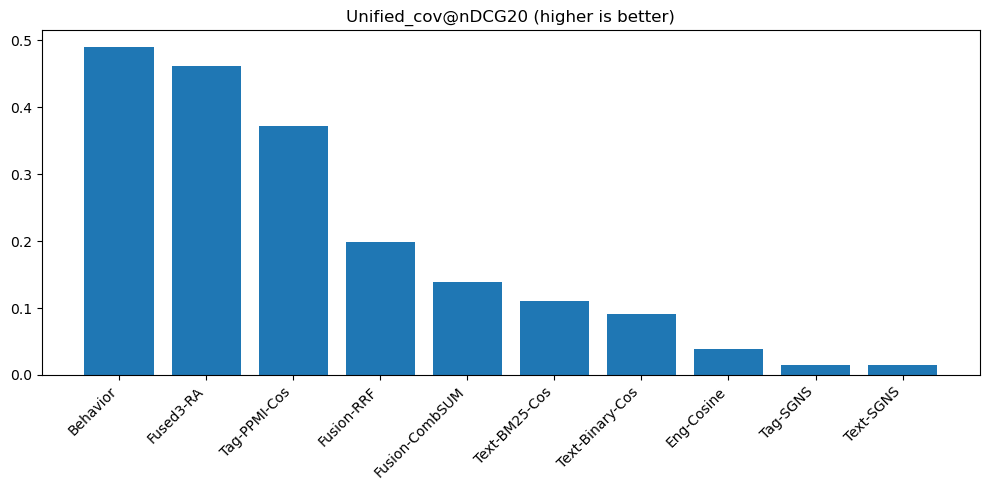

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_unified_cov_ndcg20.png


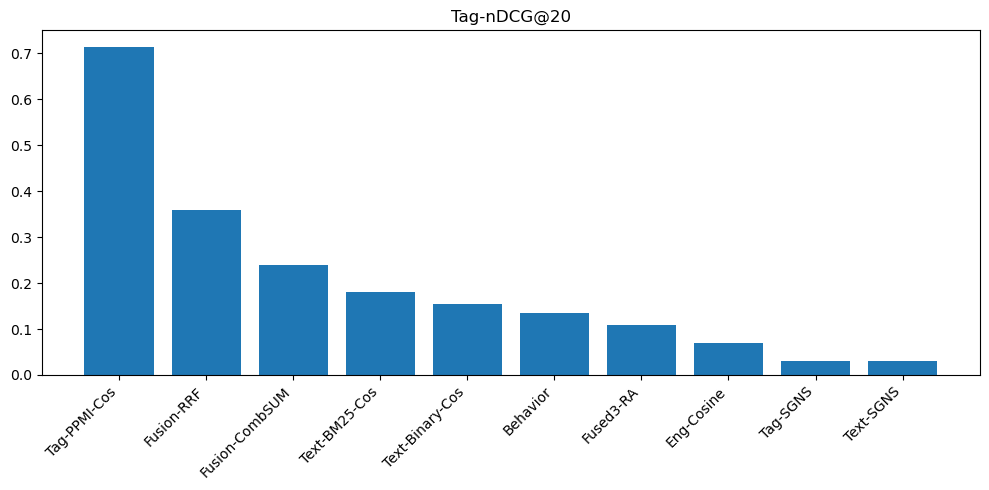

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_tag_ndcg20.png


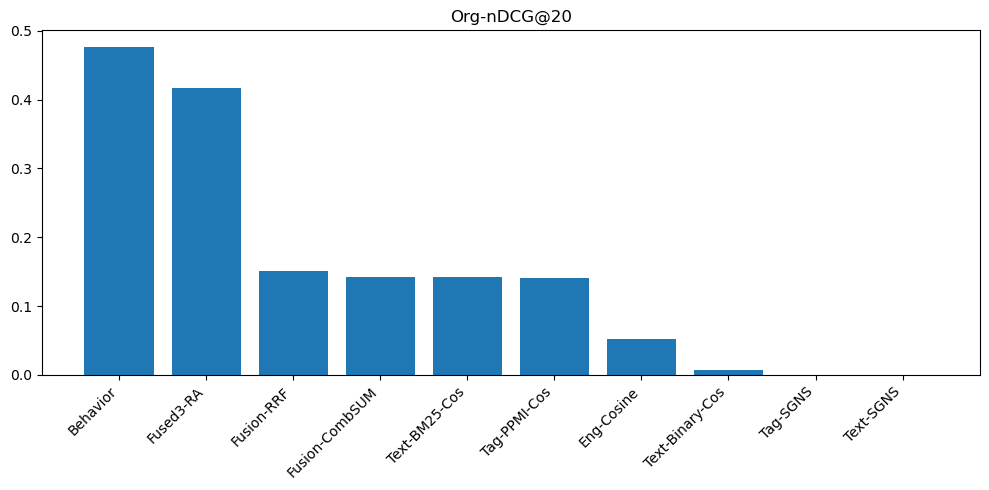

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_org_ndcg20.png


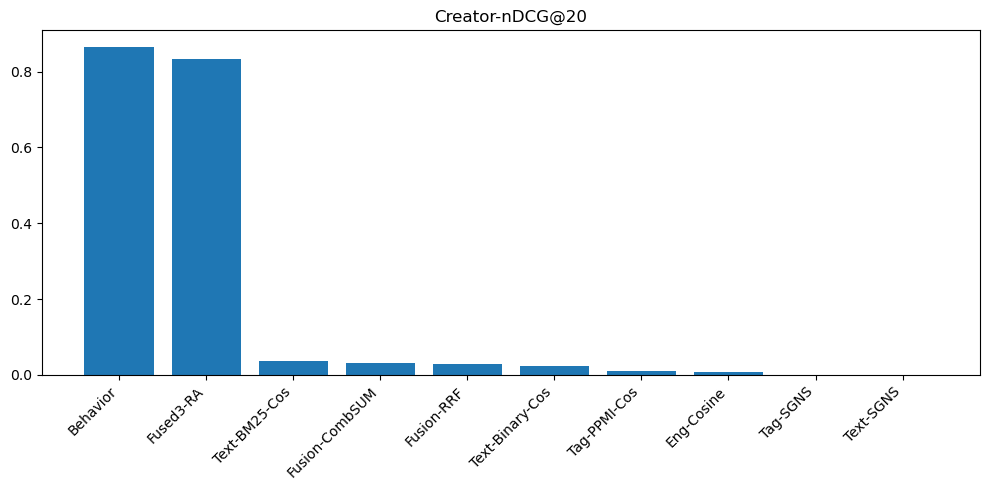

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_creator_ndcg20.png


In [42]:
# =========================
# Step 10.5 · Execute: 读表→合并→补全→统一指标→可视化
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) 读入并合并
dfs = []
for fp in METRIC_FILES:
    if fp.exists():
        df = pd.read_csv(fp)
        df["__src__"] = fp.name
        dfs.append(df)
        print(f"[LOAD] {fp.name} rows={len(df)}")
    else:
        print(f"[MISS] {fp.name} (skip)")
if not dfs:
    raise FileNotFoundError("[FATAL] 未找到任何 metrics_*.csv")

allm = pd.concat(dfs, ignore_index=True)

# 2) 规范列名集合（缺失则补 NaN/0）
need_cols = [
    "method",
    "Tag-nDCG@20","Tag-MAP@20","Tag-MRR@20","Tag-P@20","Tag-R@20","Tag-Coverage",
    "Org-nDCG@20","Org-MAP@20","Org-MRR@20","Org-P@20","Org-R@20","Org-Coverage",
    "Creator-nDCG@20","Creator-MAP@20","Creator-MRR@20","Creator-P@20","Creator-R@20","Creator-Coverage",
    "Unified@nDCG20","Unified_cov@nDCG20",
]
for c in need_cols:
    if c not in allm.columns:
        allm[c] = np.nan

# 3) 若缺少统一指标，则补充计算
mask_uni = allm["Unified@nDCG20"].isna()
if mask_uni.any():
    allm.loc[mask_uni, "Unified@nDCG20"] = (
        W_TAG*allm.loc[mask_uni, "Tag-nDCG@20"].fillna(0.0) +
        W_ORG*allm.loc[mask_uni, "Org-nDCG@20"].fillna(0.0) +
        W_CRE*allm.loc[mask_uni, "Creator-nDCG@20"].fillna(0.0)
    )

mask_u2 = allm["Unified_cov@nDCG20"].isna()
if mask_u2.any():
    num = (
        W_TAG*allm["Tag-Coverage"].fillna(0.0)*allm["Tag-nDCG@20"].fillna(0.0) +
        W_ORG*allm["Org-Coverage"].fillna(0.0)*allm["Org-nDCG@20"].fillna(0.0) +
        W_CRE*allm["Creator-Coverage"].fillna(0.0)*allm["Creator-nDCG@20"].fillna(0.0)
    )
    den = (
        W_TAG*allm["Tag-Coverage"].fillna(0.0) +
        W_ORG*allm["Org-Coverage"].fillna(0.0) +
        W_CRE*allm["Creator-Coverage"].fillna(0.0)
    ).replace(0, np.finfo(float).eps)
    allm.loc[mask_u2, "Unified_cov@nDCG20"] = (num/den)

# 4) 去重（同名方法留最新一条）
#    若你希望指定优先顺序，可在这里按 __src__ 排序决定保留哪一个
allm["_ts"] = allm.index.values
allm = allm.sort_values(["method","_ts"], ascending=[True, False]).drop_duplicates(["method"], keep="first").drop(columns=["_ts"])

# 5) 打标签（用于图例分组）
def label_group(m):
    m = str(m).lower()
    if "fused3" in m or "ra" in m and "fusion" not in m:
        return "Our-RA (Graph Fusion)"
    if "behavior" in m and "fusion" not in m:
        return "Behavior-Only"
    if "sgns" in m:
        return "SGNS (Walk-based)"
    if "fusion-" in m:
        return "Fusion Baselines (RRF/CombSUM)"
    if "ppmi" in m or "bm25" in m or "binary" in m or "eng-cos" in m or "eng-cosine" in m:
        return "Classical Non-Embedding"
    return "Others"

allm["group"] = allm["method"].apply(label_group)

# 6) 保存总表
allm.to_csv(OUT_ALL, index=False)
print(f"[SAVE] {OUT_ALL} rows={len(allm)}")

# 7) 排序与展示（按覆盖率加权统一指标）
ranked = allm.sort_values("Unified_cov@nDCG20", ascending=False).reset_index(drop=True)
display_cols = [
    "method","group","Unified_cov@nDCG20","Unified@nDCG20",
    "Tag-nDCG@20","Org-nDCG@20","Creator-nDCG@20",
    "Tag-Coverage","Org-Coverage","Creator-Coverage"
]
print("[TOP] by Unified_cov@nDCG20")
display(ranked[display_cols].head(20))

# 8) 可视化（matplotlib，无 seaborn，无配色指定）
def _barplot(df, xcol, title, outfile):
    df = df.copy().sort_values(xcol, ascending=False)
    plt.figure(figsize=(10, 5))
    plt.bar(df["method"], df[xcol])
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"[FIG] saved {outfile}")

# 统一指标（覆盖率加权）
_barplot(ranked, "Unified_cov@nDCG20", "Unified_cov@nDCG20 (higher is better)", FIG_UNI)

# 各任务 nDCG@20
_barplot(ranked, "Tag-nDCG@20",     "Tag-nDCG@20",     FIG_TAG)
_barplot(ranked, "Org-nDCG@20",     "Org-nDCG@20",     FIG_ORG)
_barplot(ranked, "Creator-nDCG@20", "Creator-nDCG@20", FIG_CRE)


[LOAD] metrics_all.csv rows=10


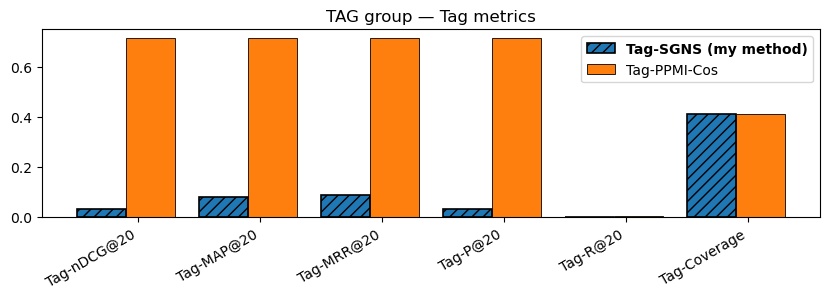

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_tag_Tag.png


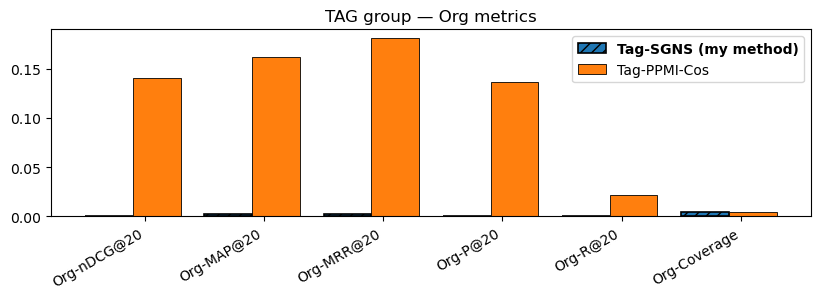

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_tag_Org.png


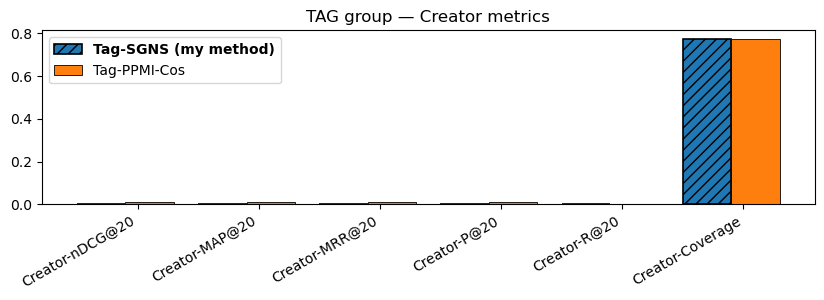

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_tag_Creator.png


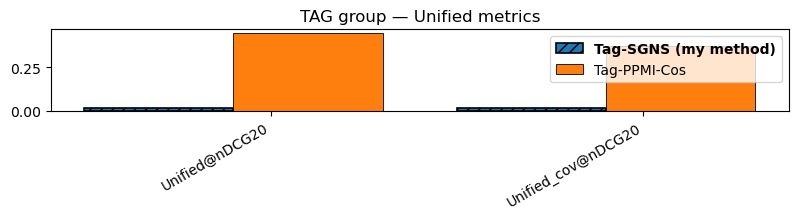

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_tag_Unified.png


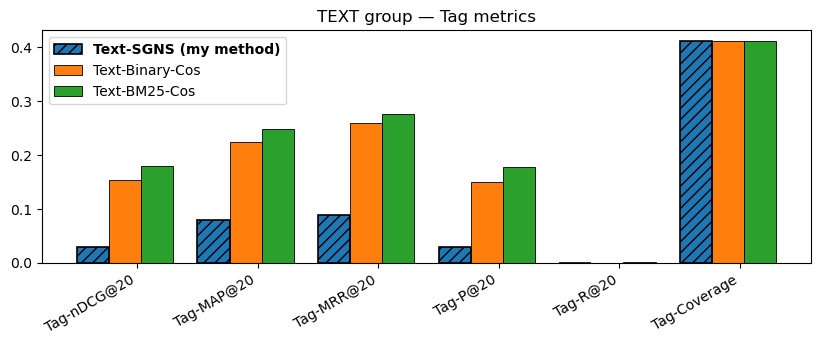

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_text_Tag.png


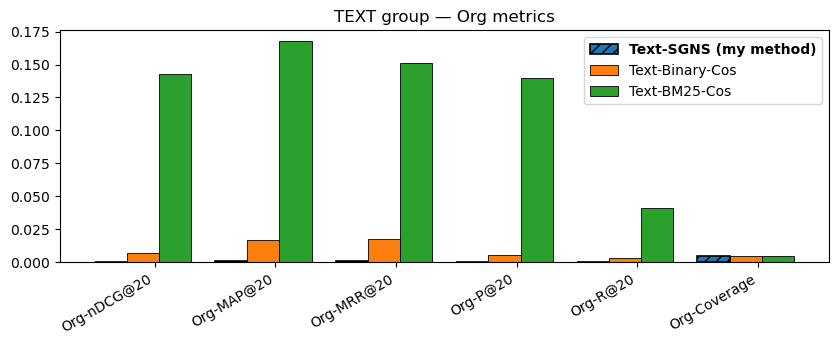

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_text_Org.png


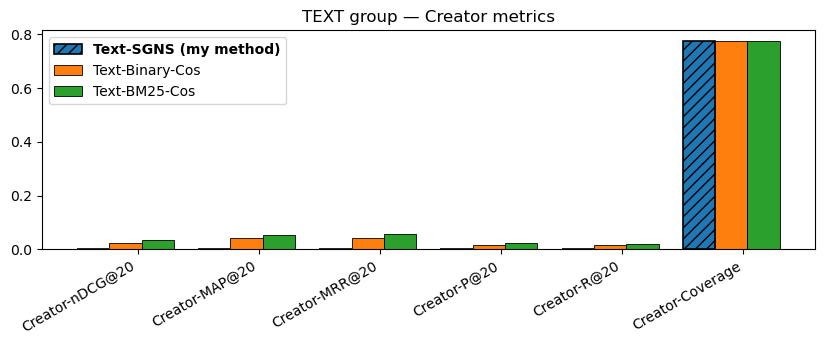

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_text_Creator.png


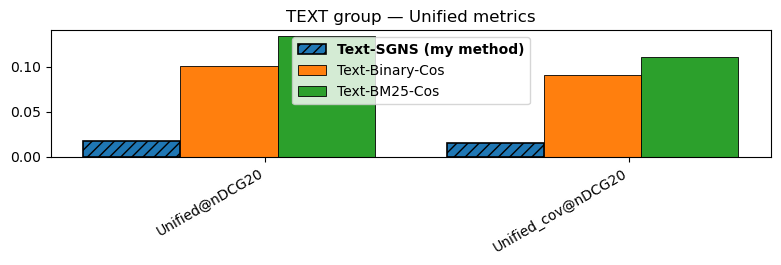

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_text_Unified.png


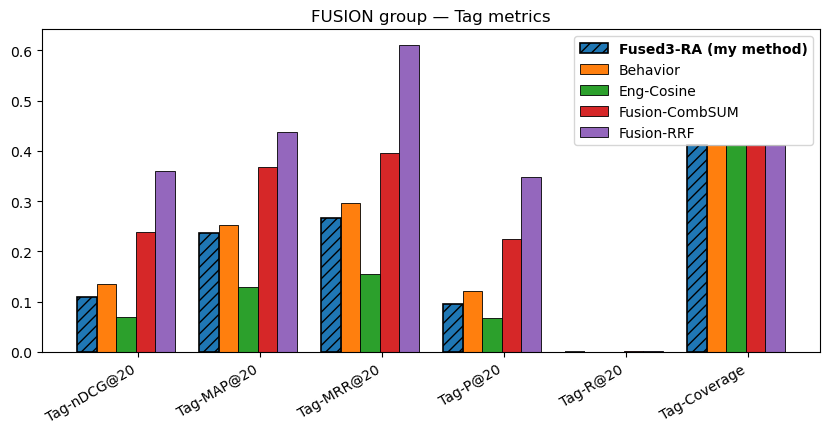

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_fusion_Tag.png


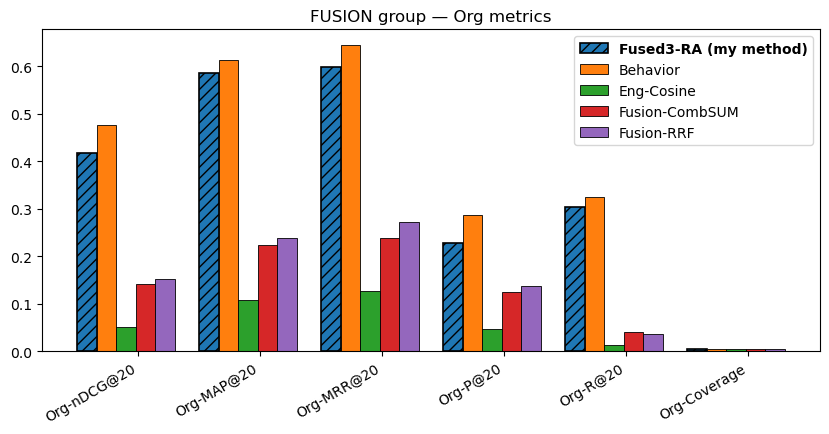

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_fusion_Org.png


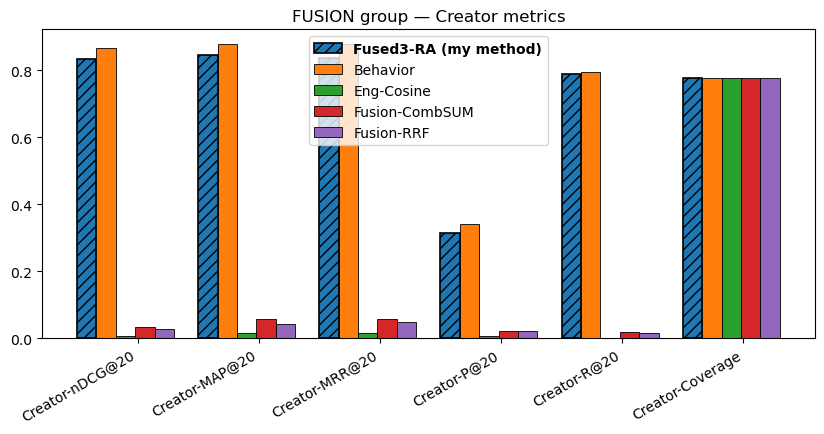

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_fusion_Creator.png


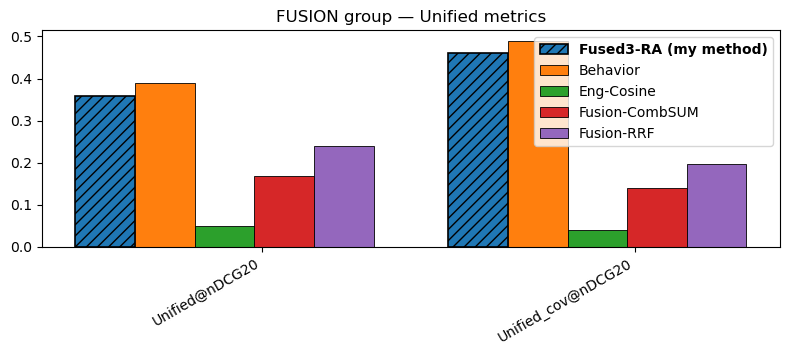

[FIG] saved /home/koyo/workspace/recsys/tmp/fig_group_fusion_Unified.png
[DONE] Grouped plots generated under ./tmp/


In [45]:
# =========================================
# Step 10.5C · Grouped Plots (tag / text / fusion)
# =========================================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TMP_DIR = Path("./tmp").resolve()
IN_ALL  = TMP_DIR / "metrics_all.csv"

# 需要的列
FAMILIES = {
    "Tag":      ["Tag-nDCG@20","Tag-MAP@20","Tag-MRR@20","Tag-P@20","Tag-R@20","Tag-Coverage"],
    "Org":      ["Org-nDCG@20","Org-MAP@20","Org-MRR@20","Org-P@20","Org-R@20","Org-Coverage"],
    "Creator":  ["Creator-nDCG@20","Creator-MAP@20","Creator-MRR@20","Creator-P@20","Creator-R@20","Creator-Coverage"],
    "Unified":  ["Unified@nDCG20","Unified_cov@nDCG20"],
}

# 读取总表
if not IN_ALL.exists():
    raise FileNotFoundError(f"[FATAL] not found: {IN_ALL}")
df = pd.read_csv(IN_ALL)
print(f"[LOAD] metrics_all.csv rows={len(df)}")

# 统一小写用于规则匹配（保持原列不变）
def _norm(s): return str(s).strip().lower()

# 三组划分规则（只保留 tag/text/fusion 三组）
def group_of(method_name: str) -> str:
    m = _norm(method_name)
    if ("fusion-" in m) or ("fused" in m) or ("ra" in m) or ("beh" in m):
        return "fusion"
    if ("text" in m):
        return "text"
    if ("tag" in m) or ("ppmi" in m):
        return "tag"
    # 其他无法归类的，放到 fusion，避免遗漏
    return "fusion"

df["__group__"] = df["method"].apply(group_of)

# 标注“我的方法”（每组最多标一个主方法）
def is_my_method(method_name: str, group_key: str) -> bool:
    m = _norm(method_name)
    if group_key == "tag":
        # 你的 tag 视图主方法
        return ("tag" in m) and ("sgns" in m)
    if group_key == "text":
        # 你的 text 视图主方法
        return ("text" in m) and ("sgns" in m)
    if group_key == "fusion":
        # 你的三视图融合主方法
        return ("fused3" in m and "ra" in m) or (m.startswith("fused") and "ra" in m) or (m == "fused3-ra")
    return False

# 画图函数：每个 group × 每个指标族 = 一张图
OUT_DIR = TMP_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

def plot_group_family(gdf: pd.DataFrame, group_name: str, family_name: str, metrics: list):
    # 方法顺序：我的方法优先，其他按字母序
    methods = list(gdf["method"].unique())
    my_flags = [is_my_method(m, group_name) for m in methods]
    # 把“我的方法”提前
    methods = [m for m,flag in sorted(zip(methods, my_flags), key=lambda x: (not x[1], x[0].lower()))]
    # 重新计算 my_flags
    my_flags = [is_my_method(m, group_name) for m in methods]

    # 数据矩阵：行=方法，列=指标
    M = len(methods)
    K = len(metrics)
    mat = np.zeros((M, K), dtype=float)
    cov_cols = {"Tag-Coverage","Org-Coverage","Creator-Coverage"}
    for i, m in enumerate(methods):
        row = gdf[gdf["method"] == m].head(1)
        for j, met in enumerate(metrics):
            if met in row.columns:
                val = row.iloc[0].get(met, np.nan)
            else:
                val = np.nan
            # Coverage 也照常画；数值一般在 [0,1]
            mat[i, j] = float(val) if pd.notna(val) else 0.0

    # 画 grouped bar
    x = np.arange(K)
    width = max(0.8 / max(M, 1), 0.15)  # 控制总宽度
    fig = plt.figure(figsize=(max(8, 1.4*K), 1.0 + 0.45*M + 0.2*K))

    bar_containers = []
    for i, m in enumerate(methods):
        offsets = x - 0.5 + width/2 + i*width
        bars = plt.bar(offsets, mat[i], width=width, label=m, edgecolor='black', linewidth=0.6)
        # 给“我的方法”加 hatch + 边线强调
        if my_flags[i]:
            for b in bars:
                b.set_hatch("///")
                b.set_linewidth(1.2)
        bar_containers.append(bars)

    plt.xticks(x, metrics, rotation=30, ha="right")
    plt.title(f"{group_name.upper()} group — {family_name} metrics")
    plt.tight_layout()

    # 构造图例，并将“我的方法”加粗 + 追加 (my method)
    handles, labels = [], []
    for i, bars in enumerate(bar_containers):
        lbl = methods[i]
        if my_flags[i]:
            lbl = f"{lbl} (my method)"
        handles.append(bars)
        labels.append(lbl)
    leg = plt.legend(handles=[h[0] for h in handles], labels=labels, loc="best", frameon=True)
    # 设置图例中“我的方法”加粗
    for t in leg.get_texts():
        if "(my method)" in t.get_text():
            t.set_fontweight("bold")

    out_png = OUT_DIR / f"fig_group_{group_name}_{family_name}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[FIG] saved {out_png}")

# 对每个分组生成四类图
groups = ["tag","text","fusion"]
for g in groups:
    sub = df[df["__group__"] == g].copy()
    if sub.empty:
        print(f"[WARN] group={g} is empty; skip.")
        continue
    for fam, cols in FAMILIES.items():
        # 仅保留存在于表中的列（防止缺失）
        cols_exist = [c for c in cols if c in sub.columns]
        if not cols_exist:
            print(f"[WARN] group={g} family={fam} has no metrics; skip.")
            continue
        plot_group_family(sub, g, fam, cols_exist)

print("[DONE] Grouped plots generated under ./tmp/")
